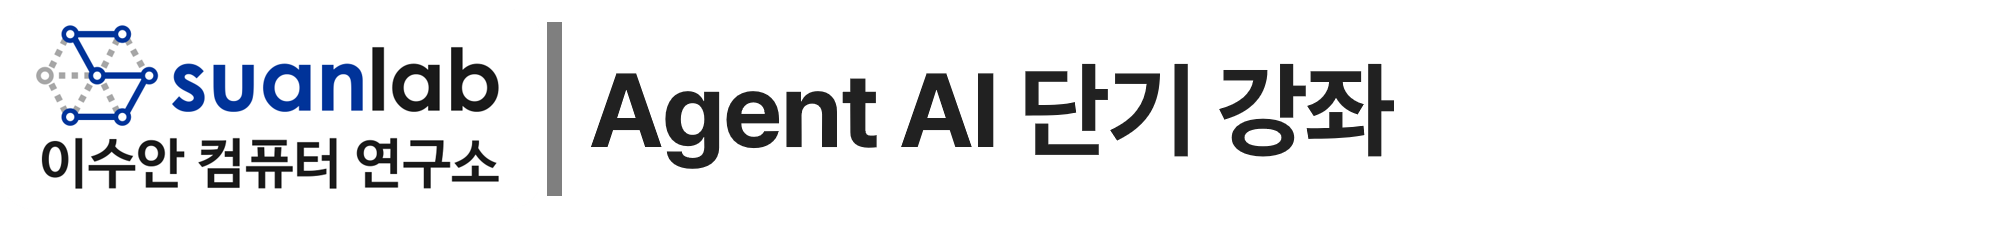

# Claude API & Custom Tool-Use

- 이 노트북 하나로 **"Claude를 호출하는 법"** 부터 **"도구를 쓰는 에이전트를 직접 만드는 법"** 까지
끊김 없이 따라갈 수 있음
- 셀을 반드시 **위에서 아래로** 차례대로 실행

## 학습 로드맵
| 순서 | 큰 주제 | 무엇을 할 수 있게 되나 |
|------|---------|------------------------|
| **1** | Claude Messages API 기본 | 호출·응답객체·역할·stop_reason·usage·토큰비용·파라미터를 구분해 다룬다 |
| **2** | 프롬프트 엔지니어링 | system 설계 / few-shot / XML 구조화+파싱 / 체크리스트로 출력을 통제한다 |
| **3** | Tool Use (도구 사용) | 스키마 설계·`description`의 힘·tool_choice·4단계 라운드트립·에러 도구결과를 다룬다 |
| **4** | 도구 라이브러리 | calculator·search_papers·unit_convert·summarize_text·now 5종 도구를 만든다 |
| **5** | 에이전트 루프 | ReAct 멀티턴 루프·종료조건·토큰누적·관찰로그를 구현한다 |
| **6** | 실습 TODO·도전·복습 | 직접 도구를 추가하고, 체크포인트로 스스로 점검한다 |

> 앞으로 다른 노트북에서도 `MODEL`/`call_with_retry`/`search_papers` 패턴을 **그대로 재사용**

### 📖 노트북을 읽는 법 (처음 사용자)
- **마크다운 셀(지금 이 셀처럼 글만 있는 칸)** = 개념 설명. 읽기만 하면 됨
- **코드 셀(왼쪽에 `[ ]`/실행버튼이 있는 칸)** = `Shift+Enter`로 실행. 위에서부터 순서대로
- 🔧 / 🪙 / ⚠️ 같은 이모지는 **로그를 눈에 띄게** 하려는 장치일 뿐, 코드 동작과 무관
- 셀 출력이 빨간 에러로 멈추면, **그 위 셀들을 모두 실행했는지** 먼저 확인하기 (변수 정의 순서 문제가 대부분)

## 환경 준비
- Colab은 **세션마다** 패키지를 새로 설치해야 함
- 런타임이 끊기거나 재시작되면 이 셀부터 다시 실행  
(로컬 Jupyter라면 한 번만 설치하면 됨)

> 💡 `-q`는 quiet(설치 로그 최소화) 옵션. 설치는 보통 5~15초

In [1]:
!pip install -q anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 929.8/929.8 kB 11.6 MB/s eta 0:00:00


### API Key 안전하게 불러오기
- 키를 코드에 직접 쓰면 노트북을 공유하거나 GitHub에 올릴 때 **그대로 유출**
- 한 번 유출된 키는 폐기·재발급해야 하므로 처음부터 안전하게 다룸
- Colab 왼쪽 🔑(Secrets) 패널에 `ANTHROPIC_API_KEY` 이름으로 키를 등록하고, 해당 노트북에서 **접근 권한 토글**을 켜두기
- 아래 셀은 그 값을 환경변수로 옮김

In [2]:
import os
# 키 로딩 순서: ① Colab Secrets(userdata) 우선 → ② 실패하면 getpass 입력 폴백.
# Colab이 아닌 로컬 환경이나 Secrets 미등록 시 import/get이 실패하므로 except로 안전하게 폴백한다.
# 키를 코드 셀에 하드코딩하면 노트북 공유 시 유출되니 절대 금지.
try:
    from google.colab import userdata
    os.environ['ANTHROPIC_API_KEY'] = userdata.get('ANTHROPIC_API_KEY')
    print('Colab Secrets에서 키 로딩 완료')
except Exception:
    # 폴백: 화면에 노출되지 않게 getpass로 입력받는다(키 누락 시 친절 안내).
    from getpass import getpass
    os.environ['ANTHROPIC_API_KEY'] = getpass('ANTHROPIC_API_KEY를 입력하세요(왼쪽 🔑 Secrets 등록을 권장): ')
    print('입력값으로 키 설정 완료')

Colab Secrets에서 키 로딩 완료


### 클라이언트 생성 & 모델 상수
- 모든 호출은 `client` 한 개를 통해 나감
- 그리고 모델명은 **`MODEL` 상수 한 곳**에서만 관리
- 이렇게 하면 모델을 바꿀 때 이 한 줄만 고치면 노트북 전체에 반영 (오타·불일치 방지)

In [3]:
import json
import anthropic

# Anthropic() 은 위에서 설정한 환경변수 ANTHROPIC_API_KEY 를 자동으로 읽는다.
client = anthropic.Anthropic()

# 모델명은 '여기 한 곳'에서만 관리한다(노트북 전체가 이 상수를 참조).
MODEL = 'claude-sonnet-4-6'
print('준비 완료. 사용 모델:', MODEL)

준비 완료. 사용 모델: claude-sonnet-4-6


> 💡 **왜 상수로 빼나?** 모델명을 셀마다 문자열로 적으면 한 군데서 오타가 나도 찾기 어렵고,
> 최신 모델로 교체할 때 모든 셀을 뒤져야 함  
`MODEL` 한 곳 → 교체·점검을 **한 줄로 격리**
>
> 📎 참고: 정확한 문자열은 `claude-sonnet-4-6` 이고, `claude-sonnet-4-6-20251114` 같은 **날짜 접미사를 붙이지 마세요** (강의 자료에서는 접미사 없는 별칭으로 통일)

---
# Claude Messages API 기본

> 🎯 **목표:** "Claude를 부른다"는 것이 실제로 무엇을 주고받는 일인지 몸으로 익히기
> 응답이 **단순 문자열이 아니라 구조화된 객체**라는 점, 그리고 그 객체의 각 필드가 무엇을 뜻하는지가 핵심

## 용어 워밍업
| 용어 | 쉬운 설명 |
|------|-----------|
| **Messages API** | Claude에게 "대화 기록(messages)"을 통째로 보내고 다음 한 마디를 받는 창구 |
| **role** | 각 메시지의 발화자. `user`(우리) / `assistant`(Claude) / (system은 별도 인자) |
| **content block** | 응답을 이루는 조각. 텍스트 블록·도구호출 블록 등 **여러 개**가 리스트로 온다 |
| **stop_reason** | Claude가 **왜 말을 멈췄는지**. `end_turn`(할 말 끝) / `tool_use`(도구 호출 필요) / `max_tokens`(길이 한도) |
| **usage / token** | 입출력 **토큰 수** = 곧 **비용**. 토큰은 단어보다 잘게 쪼갠 단위 |

## 첫 호출과 응답 '객체' 해부
`messages.create()`의 가장 기본 인자는 단 3개:
- `model` — 어떤 모델을 쓸지 (`MODEL` 상수)
- `max_tokens` — **응답** 최대 토큰 수 (**필수**로 안 주면 에러)
- `messages` — 대화 기록 리스트. 각 원소는 `{"role": ..., "content": ...}`
- 응답 `resp`는 문자열이 아니라 **여러 필드를 가진 객체**로 하나씩 꺼내 보기

In [4]:
resp = client.messages.create(
    model=MODEL,
    max_tokens=300,
    messages=[{'role': 'user', 'content': 'Agent AI를 한 문장으로 설명해줘.'}],
)
print('stop_reason  :', resp.stop_reason)        # 왜 멈췄나 (보통 end_turn)
print('usage        :', resp.usage)              # 입출력 토큰 = 비용
print('content 타입 :', type(resp.content).__name__, '(블록들의 리스트)')
print('첫 블록 타입 :', resp.content[0].type)    # 'text' (도구를 안 줬으니 텍스트)
print('-' * 55)
print('실제 답변    :')
print(resp.content[0].text)                      # 텍스트 블록의 .text 만 꺼낸다

stop_reason  : end_turn
usage        : Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='global', input_tokens=24, output_tokens=93, output_tokens_details=None, server_tool_use=None, service_tier='standard')
content 타입 : list (블록들의 리스트)
첫 블록 타입 : text
-------------------------------------------------------
실제 답변    :
**Agent AI**란, 스스로 목표를 설정하고 계획을 수립하여 도구(Tool)를 활용하고 행동(Action)을 반복적으로 실행함으로써 복잡한 작업을 자율적으로 완수하는 AI 시스템입니다.


> 💡 **왜 `content`가 리스트인가?**   
한 번의 응답에 텍스트 블록·도구 호출 블록·생각 블록 등 **여러 블록**이 함께 올 수 있기 때문  
그래서 항상 `resp.content[0].text`처럼 "**원하는 타입의 블록을 골라서**" 꺼냄  
`resp.content`를 통째로 출력하면 객체가 그대로 찍혀 보기 어려움 → 이게 입문자 단골 실수 1번

## role 이해하기 — user / assistant / system
- 대화는 **메시지들의 리스트**
- 핵심 규칙 3가지:
  1. `messages`는 **`user`로 시작**
  2. `user` ↔ `assistant`가 **번갈아** 나옴 (같은 role 연속도 가능하지만 보통 번갈아)
  3. **`system`은 `messages` 안에 넣지 않고** 별도 인자(`system=...`)로 줌 (역할·규칙 설정용)
- 아래는 "여러 메시지로 이뤄진 대화"를 한 번에 보내는 예
- Claude는 전체 맥락을 보고 답함

In [5]:
resp = client.messages.create(
    model=MODEL, max_tokens=200,
    system='너는 한국어로만 답하는 친절한 IT 강사다.',   # ← 역할/규칙은 system 으로
    messages=[
        {'role': 'user',      'content': 'LLM이 뭐야?'},
        {'role': 'assistant', 'content': '대규모 언어모델로, 다음 단어를 예측하도록 학습된 모델입니다.'},
        {'role': 'user',      'content': '그럼 에이전트는 그것과 뭐가 달라?'},   # 앞 맥락 이어서 질문
    ],
)
print(resp.content[0].text)

# AI 에이전트 vs LLM 차이점

## LLM (대규모 언어 모델)
- **단순히 텍스트를 입력받아 텍스트를 출력**하는 모델
- 질문하면 답변하고 **끝**
- 스스로 행동하거나 결정을 내리지 못함
- 예: ChatGPT에게 질문하면 답변만 해줌

---

## AI 에이전트 (Agent)
- LLM을 **두뇌**로 사용하지만, 거기서 더 나아감
- **스스로 계획을 세우고, 행동하고, 결과를 확


> 💡 **system vs user 한 줄 정리**  
`system` = "너는 누구이고 어떤 규칙을 따른다"(역할/정책)  
`user` = "이번에 해줄 일"(과제). 같은 질문도 system이 바뀌면 답의 **톤·형식**이 확 달라짐

## stop_reason 읽기 — Claude는 '왜' 멈췄나
`stop_reason`은 디버깅·에이전트 제어의 **핵심 신호**

| 값 | 의미 | 우리가 할 일 |
|----|------|--------------|
| `end_turn` | 할 말을 다 했다 | 그대로 답변 사용 |
| `tool_use` | 도구를 호출해야 한다(파트 C) | 도구 실행 후 결과를 돌려준다 |
| `max_tokens` | 길이 한도에 걸려 잘렸다 | `max_tokens`를 늘리거나 질문을 쪼갠다 |

아래 셀은 일부러 `max_tokens`를 아주 작게 줘서 답이 **잘리는** 상황을 만들기

In [6]:
short = client.messages.create(
    model=MODEL, max_tokens=8,   # 일부러 매우 작게 → 길이 한도에서 잘릴 수 있음
    messages=[{'role': 'user', 'content': '에이전트의 정의를 아주 길고 자세히 설명해줘.'}],
)
print('stop_reason:', short.stop_reason)
print('받은 텍스트:', ''.join(b.text for b in short.content if b.type == 'text'))
print('해설: stop_reason 이 max_tokens 면 답이 잘린 것 — max_tokens 를 늘려야 한다.')

stop_reason: max_tokens
받은 텍스트: # 에이전트(Agent
해설: stop_reason 이 max_tokens 면 답이 잘린 것 — max_tokens 를 늘려야 한다.


## usage = 토큰 = 비용 (감 잡기)
- 호출할 때마다 `resp.usage`에 **입력/출력 토큰 수**가 담김
- 토큰은 영어 1단어≈1.3토큰, 한글은 더 잘게 쪼개짐
- 비용 = (입력토큰×입력단가) + (출력토큰×출력단가)로 계산
- 에이전트는 도구를 여러 번 부르며 토큰이 **누적**되므로, 토큰을 의식하는 습관이 곧 비용 관리

In [7]:
def show_cost(usage, in_price_per_mtok=3.0, out_price_per_mtok=15.0):
    '''usage 객체로 대략 비용을 추정한다(단가는 예시값, 실제 단가는 공식 안내 참고).'''
    cost_in  = usage.input_tokens  / 1_000_000 * in_price_per_mtok
    cost_out = usage.output_tokens / 1_000_000 * out_price_per_mtok
    return cost_in + cost_out

r = client.messages.create(
    model=MODEL, max_tokens=120,
    messages=[{'role': 'user', 'content': '토큰과 비용의 관계를 두 문장으로.'}],
)
print('입력 토큰 :', r.usage.input_tokens)
print('출력 토큰 :', r.usage.output_tokens)
print('대략 비용 : $%.6f  (예시 단가 기준 — 실제와 다를 수 있음)' % show_cost(r.usage))

입력 토큰 : 28
출력 토큰 : 90
대략 비용 : $0.001434  (예시 단가 기준 — 실제와 다를 수 있음)


> 💡 비용은 **출력 토큰이 보통 더 비쌈**  
(1) `max_tokens`를 과하게 크게 두지 않고,  
(2) 필요 이상으로 길게 답하라고 유도하지 않는 것이 절약의 기본

## 파라미터 실험 — `temperature`
- `temperature`(0~1)는 **무작위성**을 조절
- 낮으면 일관·보수적, 높으면 다양·창의적
- 에이전트는 보통 **낮게**(재현성·안정성) 둠
- 같은 질문을 온도만 바꿔 비교해보기
- 아래에서 정의하는 `ask_once`는 **이후 파트에서도 계속 쓰는 핵심 헬퍼** (한 줄 질문→텍스트 답)

In [8]:
def ask_once(prompt, **kw):
    '''프롬프트 한 줄을 보내고 텍스트 답만 돌려주는 헬퍼. 이후 파트에서 재사용한다.'''
    params = dict(model=MODEL, max_tokens=kw.pop('max_tokens', 200),
                  messages=[{'role': 'user', 'content': prompt}])
    params.update(kw)                                  # temperature 등 추가 인자 병합
    r = client.messages.create(**params)
    return ''.join(b.text for b in r.content if b.type == 'text')

q = '에이전트를 한 단어로 비유하면?'
print('[temp=0.0]', ask_once(q, temperature=0.0))     # 보수적·일관
print('[temp=1.0]', ask_once(q, temperature=1.0))     # 다양·창의적

[temp=0.0] # 에이전트를 한 단어로 비유하면?

## **"집사"** 🎩

---

**이유:**
- 주인(사용자)의 **의도를 파악**하고
- 스스로 **판단**해서
- 필요한 일을 **알아서 처리**해주는 존재

---

다른 비유로는:
- **"심부름꾼"** - 일을 대신 처리
- **"파일럿"** - 자율적으로 운항
- **"촉수"** - 세상과 연결되는 확장 도구

어떤 맥락의 에이전트인지에 따라 달라질 
[temp=1.0] # 에이전트를 한 단어로 비유하면?

## **"대리인"** 또는 영어로 **"Butler(집사)"**

---

### 이유:
- 주인(사용자)의 **의도**를 파악하고
- 스스로 **판단**하여
- 필요한 **행동**을 대신 수행하는 존재

> 단순한 도구(Tool)가 아니라, **자율적으로 움직이는 실행자**

---

더 날카로운 비유를 원하시면 말씀해 주세요! 🎩


## 멀티턴 대화 — 맥락을 '직접' 누적
- Claude API는 **상태가 없음(stateless)**
- 즉, 이전 대화를 기억하지 못함
- "대화가 이어지는 것처럼" 보이게 하려면 **우리가 직접** 지난 메시지를 리스트에 쌓아서 매번 함께 보냄
- 이 개념은 이후 에이전트 루프에서 도구 호출 결과를 쌓는 것과 **똑같은 원리**

In [10]:
history = []   # 대화 기록을 우리가 직접 보관한다

def chat(user_text):
    history.append({'role': 'user', 'content': user_text})
    r = client.messages.create(model=MODEL, max_tokens=200, messages=history)
    reply = ''.join(b.text for b in r.content if b.type == 'text')
    history.append({'role': 'assistant', 'content': reply})   # 답도 기록에 누적
    return reply

print('Q1:', chat('내 이름은 재찬이야. 기억해줘.'))
print('Q2:', chat('방금 내가 말한 내 이름이 뭐였지?'))   # 누적했기에 맥락 유지
print('Q3:', chat('내 이름이 어떤 한자로 이루어졌을지 맞춰봐'))
print('누적된 메시지 수:', len(history))

Q1: 안녕하세요, 재찬님! 😊

말씀하신 것 기억하겠습니다. 무엇을 도와드릴까요?
Q2: 방금 말씀하신 이름은 **재찬**이에요! 😊

무엇이든 도움이 필요하시면 말씀해 주세요!
Q3: 재찬이라는 이름에 쓰일 수 있는 한자 조합을 몇 가지 추측해볼게요! 😊

---

**"재(在/才/財/載)"**
- **才** - 재능, 재주
- **在** - 존재하다
- **財** - 재물
- **載** - 싣다, 기록하다

**"찬(贊/燦/讚/璨)"**
- **贊** - 돕다, 칭찬하다
- **燦** - 빛나다, 찬란하다
- **讚** - 칭송하다
- **璨** - 보석이 빛나다

---
누적된 메시지 수: 6


> 💡 **핵심:** 멀티턴 = "이전 user/assistant 메시지를 매번 다시 보냄"  
기록을 비우면 Claude는 곧바로 맥락을 잊음  
긴 대화는 토큰이 계속 늘어나므로(=비용↑) 실무에선 요약·잘라내기로 관리

## ✅ 체크포인트
여기까지 이해했다면 다음을 **말로** 설명할 수 있어야 함
1. `resp.content`가 리스트인 이유와, 텍스트만 꺼내는 방법
2. `stop_reason`의 세 가지 값과 각 의미
3. `usage`가 왜 곧 '비용'인지
4. 멀티턴 대화를 유지하려면 무엇을 누적해야 하는지

> 막히는 항목이 있으면 해당 절로 돌아가 셀을 다시 실행해 보기  
**다음 파트로 넘어가기 전 권장 점검**

---
# 프롬프트 엔지니어링 — 출력을 '통제'하는 법

> 🎯 **목표:** 같은 모델이라도 **어떻게 묻느냐**에 따라 결과가 크게 달라짐  
> system 설계 / few-shot / XML 구조화 + 파싱 — 에이전트 개발에 가장 자주 쓰는 3대 기법을 익히기

## 한 장 요약
| 기법 | 한 줄 정의 | 언제 쓰나 |
|------|-----------|-----------|
| **System 설계** | "너는 누구/규칙은 무엇" 을 고정 | 톤·형식·정책을 일관되게 |
| **Few-shot** | 입출력 **예시 몇 개**를 보여줌 | 형식·라벨을 정확히 모방시킬 때 |
| **XML 구조화** | `<tag>...</tag>`로 답을 칸칸이 | 답의 일부를 **코드로 파싱**할 때 |

## System Prompt의 힘 (before / after)
- `system`은 Claude에게 주는 **역할·규칙 설정**
- 같은 질문도 system 유무에 따라 출력이 확 달라짐
- 아래는 "퀵소트가 뭐야?"를 (1) system 없이와 (2) 형식을 지정한 튜터 system으로 비교

In [ ]:
question = '퀵소트가 뭐야?'

before = ask_once(question, max_tokens=300)            # system 없음

after = client.messages.create(
    model=MODEL, max_tokens=300,
    system=('너는 코딩 입문자용 튜터다. 항상 (1) 한 줄 정의 (2) 일상 비유 '
            '(3) 시간복잡도 순서로, 각 한 문장씩 답한다.'),
    messages=[{'role': 'user', 'content': question}],
).content[0].text

print('===== BEFORE (system 없음) =====\n', before)
print('\n===== AFTER (튜터 system) =====\n', after)

===== BEFORE (system 없음) =====
 # 퀵소트 (Quick Sort)

## 개념
**분할 정복(Divide and Conquer)** 방식을 사용하는 정렬 알고리즘입니다.
**피벗(Pivot)** 을 기준으로 작은 값과 큰 값을 나누어 정렬합니다.

---

## 동작 방식

```
[3, 6, 8, 10, 1, 2, 1]
 ↑ 피벗 = 3

→ 피벗보다 작은 것: [1, 2, 1]
→ 피벗:             [3]
→ 피벗보다 큰 것:   [6, 8, 10]

→ 각 부분을 재귀적으로 반복!
```

---

## 코드 (Python)

```python
def quick_sort(arr):
    if len(arr) <= 1:
        return arr
    
    pivot = arr[len(arr) // 2]  # 피벗 선택
    
    left  = [x for

===== AFTER (튜터 system) =====
 **(1) 한 줄 정의**
퀵소트는 기준값(피벗)을 정해 작은 값과 큰 값으로 나누는 과정을 재귀적으로 반복하여 정렬하는 알고리즘이야.

**(2) 일상 비유**
반 친구들을 키 순서로 세울 때, 한 명을 기준으로 "나보다 작으면 왼쪽, 크면 오른쪽"으로 나누는 걸 계속 반복하는 것과 같아.

**(3) 시간복잡도**
평균적으로 O(n log n)이지만, 피벗을 최악으로 선택하면 O(n²)까지 나빠질 수 있어.


> 💡 **system 작성 팁:**  
① 역할("너는 ~ 다")  
② 규칙·형식("항상 ~ 순서로")  
③ 금지사항("~하지 마라")을 짧고 명확하게. 모호한 system은 모호한 답을 부름
에이전트의 '성격'은 거의 전부 system이 결정

## Few-shot 프롬프팅 — 예시로 형식을 가르친다
- 규칙을 길게 설명하는 대신 **입력→출력 예시 몇 쌍**을 보여주면 Claude가 형식과 톤을 모방
- 아래는 감정분류를 예시 2개만으로 학습시키는(=zero 추가설명) 패턴

In [ ]:
fewshot = client.messages.create(
    model=MODEL, max_tokens=200,
    system='입력 문장의 감정을 분류한다.',
    messages=[
        {'role': 'user',      'content': '이 영화 최고였어!'},
        {'role': 'assistant', 'content': '긍정 😊'},          # 예시 1
        {'role': 'user',      'content': '너무 실망스러웠다.'},
        {'role': 'assistant', 'content': '부정 😞'},          # 예시 2
        {'role': 'user',      'content': '음... 그냥 평범했음.'},  # 진짜 질문
    ],
).content[0].text
print('분류 결과:', fewshot)

분류 결과: 중립 😐


> 💡 **few-shot vs 설명:**  
"긍/부정/중립 중 하나로 답하라"고 길게 쓰는 것보다, **예시 2~3개**가 형식을 더 정확히 전달할 때가 많음   라벨·JSON·말투를 고정하고 싶을 때 특히 강력

## XML 구조화 출력 + 파싱 — `extract` 헬퍼
- Claude는 XML 태그 출력에 매우 강함
- 답을 `<summary>`, `<keywords>`처럼 **칸칸이** 받으면 **코드로 원하는 부분만 추출**할 수 있음
- 아래 `extract`는 **세션 2~3에서도 재사용하는 원형**

In [ ]:
import re

def extract(text, tag):
    '''<tag>...</tag> 안의 내용을 뽑는다. 없으면 None (오후 세션에서도 재사용).'''
    m = re.search(r'<%s>(.*?)</%s>' % (tag, tag), text, re.S)
    return m.group(1).strip() if m else None

xml_out = client.messages.create(
    model=MODEL, max_tokens=400,
    system='답변을 반드시 <summary>..</summary> 와 <keywords>..</keywords> 로만 구조화한다.',
    messages=[{'role': 'user', 'content': '트랜스포머를 2문장으로 요약해줘.'}],
).content[0].text

print(xml_out)
print('\n[파싱] summary  →', extract(xml_out, 'summary'))
print('[파싱] keywords →', extract(xml_out, 'keywords'))

<summary>
트랜스포머(Transformer)는 어텐션 메커니즘(Attention Mechanism)을 기반으로 입력 데이터의 각 요소 간 관계를 병렬로 처리하는 딥러닝 모델 아키텍처입니다. 기존 RNN의 순차 처리 방식을 탈피하여 학습 속도와 성능을 크게 향상시켰으며, GPT, BERT 등 현대 대형 언어 모델의 근간이 되는 구조입니다.
</summary>

<keywords>
트랜스포머, 어텐션 메커니즘, 딥러닝, RNN, BERT, GPT, 병렬 처리, 자연어 처리
</keywords>

[파싱] summary  → 트랜스포머(Transformer)는 어텐션 메커니즘(Attention Mechanism)을 기반으로 입력 데이터의 각 요소 간 관계를 병렬로 처리하는 딥러닝 모델 아키텍처입니다. 기존 RNN의 순차 처리 방식을 탈피하여 학습 속도와 성능을 크게 향상시켰으며, GPT, BERT 등 현대 대형 언어 모델의 근간이 되는 구조입니다.
[파싱] keywords → 트랜스포머, 어텐션 메커니즘, 딥러닝, RNN, BERT, GPT, 병렬 처리, 자연어 처리


> 💡 **왜 XML인가?**  
JSON은 따옴표·중괄호가 본문과 섞이면 깨지기 쉽지만, XML 태그는 **여는/닫는 태그가 명확**해 정규식으로 안전하게 뽑힘  
그래서 에이전트의 '판정/플래그/하위작업' 같은 **기계가 읽을 필드**를 받을 때 XML을 즐겨 사용 (`<verdict>`, `<flags>` 등)

## 방어적 파싱 — 형식이 어긋나도 죽지 않게
- 모델이 가끔 형식을 안 지킬 수 있음
- `extract`가 `None`을 돌려줄 때를 **항상 대비**하기
- 아래는 파싱 실패 시 **기본값**으로 안전하게 넘어가는 패턴 (에이전트 견고성의 기본)

In [ ]:
raw = client.messages.create(
    model=MODEL, max_tokens=300,
    system='답을 <verdict>ok 또는 no</verdict> 로 시작해라.',
    messages=[{'role': 'user', 'content': '1+1은 2가 맞아?'}],
).content[0].text

verdict = (extract(raw, 'verdict') or 'unknown').lower()   # None 이면 'unknown' 으로 폴백
print('원문:', raw[:80], '...')
print('안전 파싱된 verdict:', verdict)
print('해설: extract 결과가 None 일 수 있으니 항상 (... or 기본값) 으로 받는다.')

원문: <verdict>ok</verdict>

네, 맞습니다! **1 + 1 = 2** 입니다. ✅

이는 기본적인 산술 법칙으로, 수학의 가장 기초 ...
안전 파싱된 verdict: ok
해설: extract 결과가 None 일 수 있으니 항상 (... or 기본값) 으로 받는다.


## 체크리스트 & 표 유도 — 형식 지정의 또 다른 얼굴
- "표로 정리해줘", "단계별 체크리스트로" 같은 **형식 지시**도 강력한 프롬프트 기법
- 모델 출력을 사람이 읽기 좋게/이후 가공하기 좋게 만드는 실전 습관

In [ ]:
checklist = ask_once(
    '에이전트 프로젝트를 시작할 때 점검할 항목 4개를 "- [ ] 항목" 체크리스트 형식으로만 답해줘.',
    max_tokens=300)
print(checklist)

- [ ] 에이전트의 목적과 역할 명확히 정의하기
- [ ] 사용할 LLM 모델 및 도구(Tools) 선정하기
- [ ] 메모리 및 상태 관리 방식 설계하기
- [ ] 보안 및 오류 처리 정책 수립하기


## ⚠️ 자주하는 실수
| 실수 | 증상 | 올바른 방법 |
|------|------|-------------|
| system에 너무 많은 규칙을 욱여넣음 | 일부만 지켜짐 | 핵심 규칙 3~5개로 압축, 순서·형식 명시 |
| few-shot 예시 형식이 들쭉날쭉 | 출력도 들쭉날쭉 | 예시들의 **형식을 통일**(라벨·구두점까지) |
| `extract` 결과를 검사 없이 사용 | `None`에 `.lower()` → 에러 | `(extract(...) or 기본값)`로 폴백 |


## ✅ 체크포인트
- system / few-shot / XML 중 **'코드로 파싱할 답'** 에 가장 알맞은 것은? → XML 구조화
- `extract`가 None을 줄 수 있는 이유와 방어법을 설명할 수 있는가?

---
# Tool Use (도구 사용) — Claude에게 '손과 발'을 달기

> 🎯 **목표:** LLM은 혼자서는 검색·계산·외부 조회를 못함  
**도구 목록**을 주면 Claude가 "무엇을 호출할지" **요청**하고, **실제 실행은 우리 코드**가 함  
이 분업이 에이전트의 심장

## 4단계 라운드트립


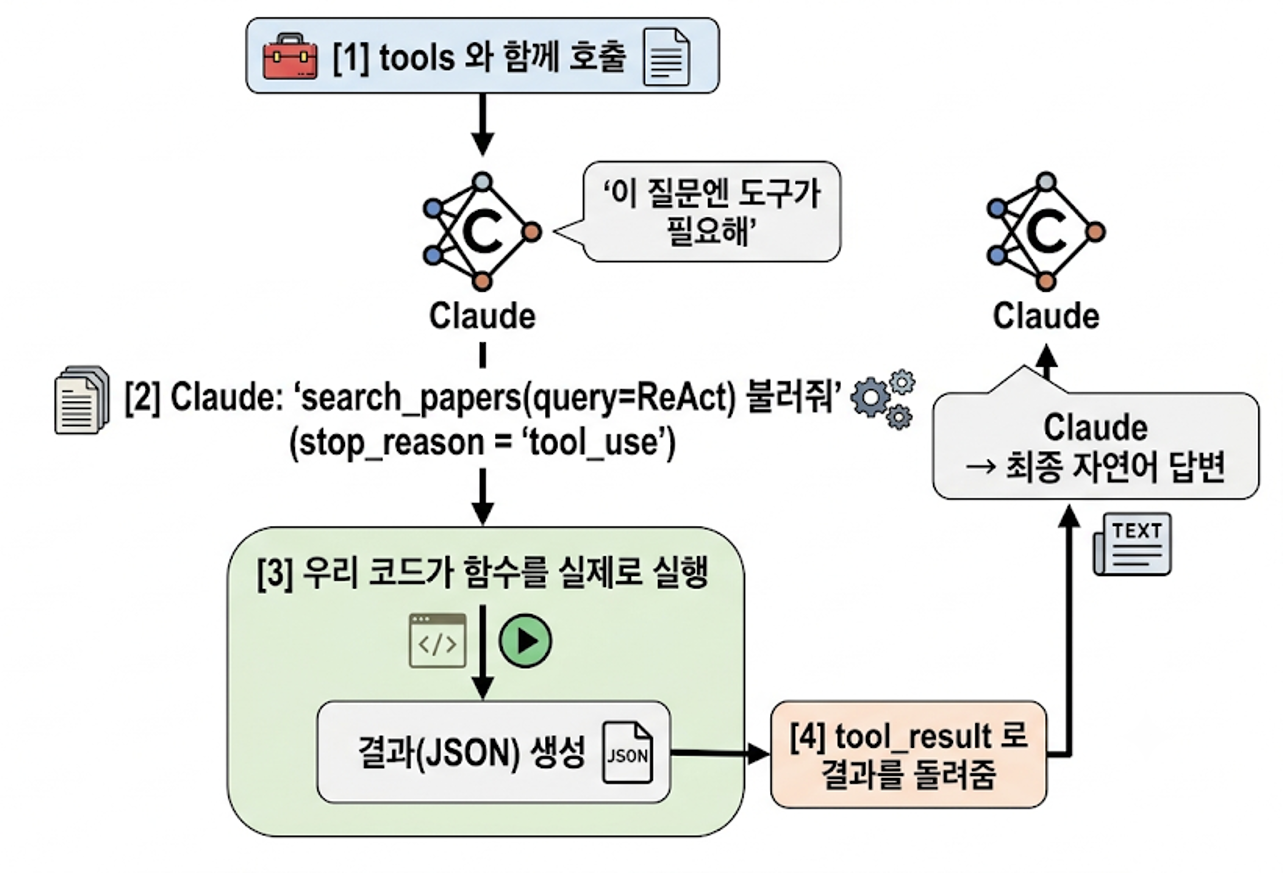

**핵심:** Claude는 "무엇을 부를지"만 정하고, **실행 책임은 전적으로 우리(코드)** 에게 있음  
이 경계가 보안·안전의 출발점 (모델이 임의 코드를 직접 실행하지 못함)

## 용어 워밍업

| 용어 | 설명 |
|------|------|
| **tool schema** | 도구의 '사용설명서'. `name`·`description`·`input_schema`(JSON Schema) |
| **`description`** | Claude가 **언제 이 도구를 쓸지** 판단하는 근거. 가장 중요! |
| **`input_schema`** | 도구가 받을 인자의 타입·필수여부(JSON Schema 형식) |
| **tool_use 블록** | Claude의 "이 도구를 이 인자로 불러줘" 요청(`.name`, `.input`, `.id`) |
| **tool_result** | 우리가 돌려주는 실행 결과(같은 `tool_use_id` 로 매칭) |
| **`tool_choice`** | 도구 선택 강제 옵션: `auto`(기본)/`any`(아무거나 꼭)/특정도구 강제 |

## 도구 '스키마' 정의 (검색 + 계산기)
- 먼저 도구 2개의 **스키마(설명서)** 를 정의
- 아직 '구현'은 안 했음 — 지금은 Claude에게
"이런 도구가 있다"고 **알려주는 명세**만 만드는 단계
- `description`을 특히 정성껏 쓰기

In [ ]:
tools = [
    {'name': 'search_papers',
     'description': 'arXiv 학술 논문 DB에서 주제 키워드로 논문을 검색한다. 최신 연구·근거가 필요할 때 사용.',
     'input_schema': {'type': 'object',
        'properties': {
            'query': {'type': 'string', 'description': '영문 검색 키워드'},
            'max_results': {'type': 'integer', 'description': '가져올 논문 수(기본 3)'}},
        'required': ['query']}},
    {'name': 'calculator',
     'description': "사칙연산 수식을 계산한다. 예: '12*5+3'. 정확한 수치 계산이 필요할 때 사용.",
     'input_schema': {'type': 'object',
        'properties': {
            'expression': {'type': 'string', 'description': '계산할 파이썬 수식'}},
        'required': ['expression']}},
]
print('정의된 도구:', [t['name'] for t in tools])

정의된 도구: ['search_papers', 'calculator']


> 💡 **스키마 설계 원칙:**  
① `name`은 동사+목적어로 명확히(`search_papers`)  
② `description`은 "**무엇을·언제** 쓰는지"를 한 문장으로  
③ `input_schema`의 각 인자에도 `description`을 달아 Claude가 **올바른 값**을 채우게 돕기  
`required`로 필수 인자를 못 박기

## 도구 '구현' — 실제 함수 (+ 네트워크 폴백)
- 이제 스키마에 대응하는 **실제 파이썬 함수**를 만들기
- Wi-Fi/arXiv가 불안정할 수 있으므로
검색은 실패 시 **mock(가짜) 데이터**로 폴백해 데모가 끊기지 않게 하기 (단체 실습 안전장치)

> ⚠️ **검증계약:** `calculator('2+3')` 은 반드시 문자열 `'5'` 를 돌려줘야 함 (이후 자동 검증에서 확인)

In [ ]:
import urllib.request, urllib.parse
import xml.etree.ElementTree as ET

def search_papers(query, max_results=3):
    '''arXiv 검색. 네트워크/파싱 실패 또는 0건이면 mock 데이터로 폴백.'''
    try:
        params = urllib.parse.urlencode(
            {'search_query': 'all:' + query, 'start': 0, 'max_results': max_results})
        with urllib.request.urlopen(
                'http://export.arxiv.org/api/query?' + params, timeout=10) as r:
            data = r.read().decode('utf-8')
        ns = {'a': 'http://www.w3.org/2005/Atom'}
        papers = [{'title': e.find('a:title', ns).text.strip(),
                   'summary': e.find('a:summary', ns).text.strip()[:300]}
                  for e in ET.fromstring(data).findall('a:entry', ns)]
        if not papers:
            raise ValueError('결과 없음')
        return papers
    except Exception as ex:
        print('⚠️ arXiv 실패 → mock 사용:', ex)
        return [{'title': 'ReAct: Synergizing Reasoning and Acting in Language Models',
                 'summary': '추론과 행동을 번갈아 수행해 도구를 활용하고 환각을 줄이는 프레임워크.'}]

def calculator(expression):
    '''안전한 사칙연산 계산기. eval 의 내장함수를 차단해 위험 코드 실행을 막는다.'''
    return str(eval(expression, {'__builtins__': {}}, {}))

print('확인:', calculator('2+3*4'), '/', search_papers('ReAct', 1)[0]['title'][:30], '...')

확인: 14 / On the road to percent accurac ...


> ⚠️ **`eval` 보안 메모:**  
`eval(expr, {'__builtins__': {}}, {})` 는 내장함수를 비워 `__import__('os')...` 같은 위험 호출을 막음  
실무에선 `ast.literal_eval`이나 전용 파서를 권장

## `description`의 힘 — Claude는 설명을 보고 도구를 고름
- 도구를 2개 줬을 때, Claude가 **질문에 맞는 도구를 스스로 고르는지** 관찰
- 선택의 근거는 오직 `description` (도구가 필요 없는 잡담엔 아무 도구도 안 고름 → 빈 리스트)

In [ ]:
def which_tool(question):
    r = client.messages.create(model=MODEL, max_tokens=300, tools=tools,
                               messages=[{'role': 'user', 'content': question}])
    chosen = [b.name for b in r.content if b.type == 'tool_use']
    return chosen, r.stop_reason

print("'123*456 계산해줘'  →", which_tool('123*456 계산해줘'))
print("'ReAct 논문 찾아줘' →", which_tool('ReAct 논문 찾아줘'))
print("'오늘 기분 어때?'   →", which_tool('오늘 기분 어때?'))

'123*456 계산해줘'  → (['calculator'], 'tool_use')
'ReAct 논문 찾아줘' → (['search_papers'], 'tool_use')
'오늘 기분 어때?'   → ([], 'end_turn')


> 🧪 **미니 실험:**  
위 도구의 `description`을 모호하게(예: "계산기") 바꾸면 Claude가 엉뚱한 선택을 더 자주 함  
**description이 곧 라우팅 로직**이라는 점을 기억

## tool_choice — 도구 선택을 '강제'하기
기본은 `auto`(Claude가 알아서 선택)이지만, 상황에 따라 강제할 수 있음

| `tool_choice` | 의미 |
|---------------|------|
| `{'type': 'auto'}` (기본) | 필요하면 도구, 아니면 텍스트 |
| `{'type': 'any'}` | **반드시** 도구 중 하나를 쓴다(텍스트 답 금지) |
| `{'type': 'tool', 'name': 'X'}` | **특정 도구 X**를 강제 → 구조화 출력에 활용(부록서 심화) |

아래는 특정 도구를 강제해 **항상 그 도구의 입력(JSON)** 을 받는 예

In [ ]:
forced = client.messages.create(
    model=MODEL, max_tokens=300, tools=tools,
    tool_choice={'type': 'tool', 'name': 'calculator'},   # calculator 강제
    messages=[{'role': 'user', 'content': '아무 수식이나 하나 계산해줘.'}],
)
calls = [(b.name, b.input) for b in forced.content if b.type == 'tool_use']
print('강제된 도구 호출:', calls)
print('stop_reason:', forced.stop_reason)

강제된 도구 호출: [('calculator', {'expression': '123 * 456 + 789'})]
stop_reason: tool_use


> 💡 `tool_choice`로 **특정 도구를 강제**하면 자유 텍스트 대신 항상 그 도구의 `input`(검증된 JSON)을 얻음 → 이것이 **'구조화 출력(structured output)'** 기법의 핵심

## 4단계 라운드트립 — 한 단계씩 손으로
- 이제 자동 루프(파트 E) 없이 **수동으로** 4단계를 밟아보기
- 먼저 **[1~2]**: Claude가 도구 호출을 요청하는 순간

In [ ]:
messages = [{'role': 'user',
             'content': 'ReAct 프레임워크 최신 논문을 찾아서 핵심을 알려줘.'}]
resp = client.messages.create(model=MODEL, max_tokens=1024, tools=tools, messages=messages)

print('stop_reason:', resp.stop_reason)        # 'tool_use' 가 나와야 정상
for b in resp.content:
    if b.type == 'tool_use':
        print(' 요청 도구 :', b.name)
        print('      인자 :', b.input)
        print('   호출 id :', b.id, '(이 id로 결과를 매칭한다)')

stop_reason: tool_use
 요청 도구 : search_papers
      인자 : {'query': 'ReAct framework reasoning acting language model agent', 'max_results': 5}
   호출 id : toolu_018KiHMvbvrw2nuNqBcUDVbq (이 id로 결과를 매칭한다)


- **[3~4]** 이제 도구를 **실제 실행**하고, 그 결과를 `tool_result`로 돌려준 뒤 최종 답변을 받기
- 규칙 2가지: ① 직전 assistant 응답(`resp.content`)을 messages에 **그대로 추가** ② **같은 `tool_use_id`** 로 결과를 보냄 (짝이 안 맞으면 에러)

In [ ]:
# ① 직전 assistant 응답(도구 호출 포함)을 대화에 추가
messages.append({'role': 'assistant', 'content': resp.content})

# ② 요청된 각 도구를 실제 실행 → tool_result 로 모은다
TOOL_MAP = {'search_papers': search_papers, 'calculator': calculator}
tool_results = []
for b in resp.content:
    if b.type == 'tool_use':
        out = TOOL_MAP[b.name](**b.input)                    # 실제 함수 실행
        tool_results.append({'type': 'tool_result',
                             'tool_use_id': b.id,            # 같은 id 로 매칭!
                             'content': json.dumps(out, ensure_ascii=False)})

# ③ 결과를 user 메시지로 돌려주고 → 최종 답변을 받는다
messages.append({'role': 'user', 'content': tool_results})
final = client.messages.create(model=MODEL, max_tokens=1024, tools=tools, messages=messages)
print('=== 최종 답변 ===')
print(''.join(b.text for b in final.content if b.type == 'text'))

=== 최종 답변 ===
검색 결과를 바탕으로 핵심 내용을 정리해드릴게요! 🔍

---

## 🤖 ReAct 프레임워크 최신 논문 핵심 정리

---

### 📄 1. 원조 핵심 논문: **"ReAct: Synergizing Reasoning and Acting in Language Models"**

> **핵심 아이디어**: LLM의 **추론(Reasoning)**과 **행동(Acting)**을 분리하지 않고 **통합**하는 프레임워크

#### 🔑 핵심 개념
| 구분 | 설명 |
|------|------|
| **문제 인식** | 기존 LLM은 추론(Chain-of-Thought)과 행동(Tool Use)을 **따로** 연구해왔음 |
| **ReAct의 해법** | Thought → Action → Observation 사이클을 **반복**하며 추론과 행동을 동시에 수행 |
| **장점** | 중간 추론 과정이 투명하게 보여 **해석 가능성(Interpretability)** 향상 |

#### 🔄 ReAct 동작 루프
```
[Thought]  → 현재 상황을 언어로 추론
    ↓
[Action]   → 도구(검색, API 등) 호출
    ↓
[Observation] → 도구 결과 수신
    ↓
(반복) → 최종 Answer 도출
```

---

### 📄 2. 연계 논문: **"Learning From Failure: Negative Examples for LLM Agents"**

> **핵심 아이디어**: ReAct 스타일 에이전트의 **실패 사례**를 파인튜닝에 활용해 성능 향상

#### 🔑 핵심 포인트
- LLM은 언어 생성에 최적화되어 있어 **도구 사용(Tool Use)에 취약**
- **실패한 행동 경로(Negative Examples)** 를 학습 데이터로 포함 → 에이전트 성능 향상
- ReAct 루프에서 **잘못된 Action의 패턴**을 학습해 오류 반복 방지

---

### 📄 3. 연계 논문: **"Making LL

## 에러 도구 결과 — `is_error` 로 실패를 알려주기
- 도구 실행이 실패할 수도 있음 (잘못된 수식, 네트워크 오류 등)
- 그럴 땐 `tool_result`에 `"is_error": True`를 넣어 Claude에게 **"이 도구는 실패했다"** 고 알려주면, Claude가 다시 시도하거나 다른 방법을 택함
- 아래는 일부러 잘못된 수식을 던져 에러 결과를 만드는 예

In [ ]:
def run_tool_safely(name, tool_input):
    '''도구 실행을 try/except 로 감싸 (결과문자열, 에러여부) 를 돌려준다.'''
    try:
        out = TOOL_MAP[name](**tool_input)
        return json.dumps(out, ensure_ascii=False), False
    except Exception as ex:
        return '도구 실행 오류: %s' % ex, True            # is_error=True 로 알릴 내용

# 예시: 일부러 깨지는 수식
text, is_err = run_tool_safely('calculator', {'expression': '2 ++ '})
print('실행 결과:', text, '| is_error =', is_err)

# 이런 결과는 아래 형태로 Claude 에게 돌려준다(개념 확인용):
example_tool_result = {'type': 'tool_result', 'tool_use_id': 'tu_demo',
                       'content': text, 'is_error': is_err}
print('Claude 에게 보낼 tool_result 예:', example_tool_result)

실행 결과: 도구 실행 오류: invalid syntax (<string>, line 1) | is_error = True
Claude 에게 보낼 tool_result 예: {'type': 'tool_result', 'tool_use_id': 'tu_demo', 'content': '도구 실행 오류: invalid syntax (<string>, line 1)', 'is_error': True}


> 💡 **왜 굳이 실패를 알려주나?**  
에러를 숨기고 빈 결과를 주면 Claude가 같은 실수를 반복하거나 환각으로 채움  
`is_error=True`로 솔직히 알려주면 **자기수정(self-correction)** 기회를 줌

## 병렬 도구 호출 (개념)
- Claude는 한 응답에서 **여러 tool_use 블록**을 동시에 낼 수 있음 (예: 논문 검색 + 계산 동시)
- 그래서 우리 코드는 **`resp.content`의 모든 tool_use를 순회**하며 각각 실행하고, 결과를 **모두 모아** 한 번에 돌려줘야 함

## ⚠️ 자주하는 실수
| 실수 | 증상 | 올바른 방법 |
|------|------|-------------|
| `description`이 모호 | Claude가 엉뚱한 도구 선택 | "무엇을·언제" 쓰는지 한 문장으로 명확히 |
| `tool_use_id` 불일치 | 400 에러(결과 매칭 실패) | 요청의 `b.id`를 결과의 `tool_use_id`에 그대로 |
| 직전 assistant 응답 누락 | 모델이 도구 호출을 '못 본' 상태 | `messages.append({'role':'assistant','content':resp.content})` |
| tool_use 하나만 처리 | 병렬 호출 시 일부 누락 | `for b in resp.content`로 **모두** 순회 |
| `input_schema.properties` 비움 | 인자 의미 전달 안 됨 | 각 인자에 type·description 명시 |


## ✅ 체크포인트
- 4단계 라운드트립을 **순서대로** 말할 수 있는가?
- `tool_choice`의 auto / any / 특정도구 강제의 차이는?
- 도구가 실패하면 Claude에게 어떻게 알려주나? (`is_error`)

---
# 도구 라이브러리 — 도구를 늘려 에이전트를 똑똑하게

> 🎯 **목표:** 도구는 많을수록(그리고 설명이 명확할수록) 에이전트가 풀 수 있는 문제가 넓어짐  
> 기존 2개에 더해 **단위 변환·현재시각·요약** 도구를 추가하고, 모두 한 곳(`TOOL_FUNCS`)에 등록

## `unit_convert` — 표준 라이브러리만으로 만드는 도구
- 외부 패키지 없이도 유용한 도구를 만들 수 있음
- 간단한 단위 변환기를 만들어 보기 (도구 구현은 **평범한 파이썬 함수**일 뿐 — LLM과 무관하게 그냥 동작해야 함)

In [ ]:
def unit_convert(value, from_unit, to_unit):
    '''길이/무게 간단 변환. 지원: m,km,cm / kg,g / c,f(섭씨↔화씨).'''
    v = float(value)
    table = {('km', 'm'): v * 1000, ('m', 'km'): v / 1000,
             ('m', 'cm'): v * 100,  ('cm', 'm'): v / 100,
             ('kg', 'g'): v * 1000, ('g', 'kg'): v / 1000,
             ('c', 'f'): v * 9 / 5 + 32, ('f', 'c'): (v - 32) * 5 / 9}
    key = (from_unit.lower(), to_unit.lower())
    if key not in table:
        return '지원하지 않는 변환: %s→%s' % (from_unit, to_unit)
    return '%g %s = %g %s' % (v, from_unit, table[key], to_unit)

print(unit_convert(3, 'km', 'm'))
print(unit_convert(100, 'c', 'f'))
print(unit_convert(5, 'mile', 'm'))   # 미지원 → 친절 메시지

3 km = 3000 m
100 c = 212 f
지원하지 않는 변환: mile→m


## `now` — 부작용 없는 정보 조회 도구
- LLM은 '지금 몇 시'를 모름 (학습 시점에 멈춰 있음)
- 시간·날짜처럼 **실시간 정보**는
도구로 줘야 함
- 표준 라이브러리 `datetime`만 사용

In [ ]:
from datetime import datetime

def now(fmt='%Y-%m-%d %H:%M:%S'):
    '''현재 시각 문자열을 돌려준다. 실시간 정보는 모델이 모르므로 도구로 제공.'''
    return datetime.now().strftime(fmt)

print('현재 시각:', now())
print('날짜만   :', now('%Y-%m-%d'))

현재 시각: 2026-06-17 05:45:11
날짜만   : 2026-06-17


## `summarize_text` — '도구가 LLM을 부르는' 도구
- 도구 안에서 **다시 Claude를 호출**할 수도 있음 (요약·번역 등)
- `ask_once`를 재사용해 긴 텍스트를 한 문장으로 줄이는 도구를 만들기

In [ ]:
def summarize_text(text):
    '''긴 텍스트를 한국어 한 문장으로 요약. 내부에서 ask_once 로 LLM 재호출.'''
    return ask_once('다음 텍스트를 한국어 한 문장으로 요약해줘:\n' + text, max_tokens=150)

sample = ('에이전트는 계획을 세우고(Planning), 정보를 기억하며(Memory), '
          '도구를 사용해(Tool) 환경과 상호작용하는 시스템이다. ' * 2)
print('요약:', summarize_text(sample))

요약: 에이전트는 계획 수립, 정보 기억, 도구 활용을 통해 환경과 상호작용하는 시스템이다.


## 도구 스키마 모음 + 레지스트리(`TOOL_FUNCS`)
- 새 도구 3종의 **스키마**를 정의하고, 기존 2종과 합쳐 **이름→함수 매핑**(레지스트리)을 만들기
- 이 레지스트리는 에이전트 루프가 "Claude가 부른 이름으로 실제 함수를 찾는" 전화번호부

In [ ]:
extra_schemas = [
    {'name': 'unit_convert',
     'description': '길이/무게/온도 단위를 변환한다. 예: 3 km를 m로. 단위 환산이 필요할 때 사용.',
     'input_schema': {'type': 'object',
        'properties': {
            'value': {'type': 'number', 'description': '변환할 수치'},
            'from_unit': {'type': 'string', 'description': '원래 단위(km,m,cm,kg,g,c,f)'},
            'to_unit': {'type': 'string', 'description': '바꿀 단위'}},
        'required': ['value', 'from_unit', 'to_unit']}},
    {'name': 'now',
     'description': '현재 날짜와 시각을 알려준다. 오늘 날짜·지금 시간이 필요할 때 사용.',
     'input_schema': {'type': 'object',
        'properties': {'fmt': {'type': 'string', 'description': 'strftime 형식(선택)'}},
        'required': []}},
    {'name': 'summarize_text',
     'description': '긴 텍스트를 한 문장으로 요약한다. 검색 결과나 문서를 압축할 때 사용.',
     'input_schema': {'type': 'object',
        'properties': {'text': {'type': 'string', 'description': '요약할 원문'}},
        'required': ['text']}},
]

# 전체 도구 스키마(= Claude 에게 보여줄 목록)와 실행 레지스트리(= 이름→함수)
all_tools = tools + extra_schemas
TOOL_FUNCS = {'search_papers': search_papers, 'calculator': calculator,
              'unit_convert': unit_convert, 'now': now, 'summarize_text': summarize_text}

print('전체 도구 %d종:' % len(all_tools), [t['name'] for t in all_tools])

전체 도구 5종: ['search_papers', 'calculator', 'unit_convert', 'now', 'summarize_text']


> 💡 **스키마 vs 구현 vs 레지스트리** 세 가지를 구분하기:  
> ① **스키마**(`all_tools`) = Claude에게 보여줄 설명서 → `create(tools=...)`로 전달  
> ② **구현**(파이썬 함수) = 실제 동작  
> ③ **레지스트리**(`TOOL_FUNCS`) = 이름→함수 매핑. Claude가 부른 이름으로 함수를 찾는 다리  
> 세 가지가 **이름으로 일치**해야 도구가 동작

## ⚠️ 자주하는 실수
| 실수 | 증상 | 올바른 방법 |
|------|------|-------------|
| 스키마는 추가했는데 레지스트리 등록 누락 | `KeyError`(이름으로 함수 못 찾음) | `TOOL_FUNCS[이름]=함수`도 함께 |
| 스키마 `name`과 함수 키 불일치 | 도구 호출 실패 | 세 곳(스키마·구현·레지스트리) **이름 통일** |
| `required`에 선택 인자까지 넣음 | 모델이 불필요한 값 강제 입력 | 꼭 필요한 것만 `required` |


## ✅ 체크포인트
- 새 도구를 추가하는 **3단계**(스키마·구현·레지스트리)를 말할 수 있는가?
- `now`처럼 **실시간 정보**가 왜 도구여야 하는지 설명할 수 있는가?

---
# 에이전트 루프 — 가장 단순한 에이전트(ReAct) 구현

> 🎯 **목표:** 4단계를 **반복 루프**로 일반화하면 그게 바로 에이전트
> Claude가 도구를 **여러 번·여러 종류** 부를 수 있게 하고, 종료조건·토큰누적·관찰로그를 갖춤

## 안전장치 — rate limit 재시도 래퍼 (`call_with_retry`)
- 40~60명이 **동시에** 호출하면 `429 Too Many Requests`가 날 수 있음
- **지수 백오프** (1→2→4→8초로 점점 길게 대기)로 재시도
- 단, **인증/형식 오류(401/400)는 재시도해도
소용없으므로 즉시 위로 raise** (잘못된 키로 무한 재시도 방지)

In [ ]:
import time

def call_with_retry(max_retries=4, **kwargs):
    '''일시적 오류(429/529/연결)에만 지수 백오프 재시도. 영구 오류는 즉시 raise.'''
    for attempt in range(max_retries):
        try:
            return client.messages.create(**kwargs)
        # ↓ 일시적 오류만 잡는다. 인증 오류(401)·요청 형식 오류(400)는
        #   여기서 잡지 않으므로 그대로 위로 raise → 무의미한 재시도를 막는다.
        except (anthropic.RateLimitError,
                anthropic.InternalServerError,
                anthropic.APIConnectionError) as e:
            wait = 2 ** attempt   # 1, 2, 4, 8초 (단체 실습 429 완충)
            print('⏳ 재시도 %d/%d (%s) — %ds 대기' % (attempt + 1, max_retries, type(e).__name__, wait))
            time.sleep(wait)
    raise RuntimeError('재시도 초과 — 크레딧/네트워크/rate limit 확인')

print('call_with_retry 준비 완료')

call_with_retry 준비 완료


> 💡 **백오프(backoff)란?**  
실패할 때마다 대기시간을 늘려 서버 부하를 분산하는 기법  
> `2 ** attempt`는 1, 2, 4, 8초로 **지수적으로** 늘어남  
단체 호출 폭주를 완만히 흩뜨러트림

## 멀티턴 에이전트 루프 (`run_agent`)
- 드디어 핵심으로 아래 `run_agent`는 4단계 라운드를 **`for` 루프로 일반화**한 것
- `stop_reason != 'tool_use'` → 도구가 더 필요 없음 → **최종 답변 반환(루프 종료)**
- `stop_reason == 'tool_use'` → 모든 tool_use를 실행 → 결과를 돌려주고 **다음 턴**
- `max_turns` → 무한루프 안전장치(도구를 영원히 부르는 사고 방지)
- 매 턴 **토큰을 누적**해 비용을 관찰

> ⚠️ **검증계약:** 이 셀이 만드는 `answer`(문자열, 비어있지 않음)는 자동 검증에서 확인

In [ ]:
def run_agent(user_message, tools, system=None, max_turns=6, verbose=True):
    '''가장 단순한 ReAct 에이전트: 필요하면 도구를 반복 호출하다 최종 답을 낸다.'''
    messages = [{'role': 'user', 'content': user_message}]
    log = []                                   # 관찰 로그(어떤 도구를 언제 불렀나)
    tin = tout = 0                             # 누적 토큰
    for turn in range(max_turns):
        kw = dict(model=MODEL, max_tokens=1024, tools=tools, messages=messages)
        if system:
            kw['system'] = system
        resp = call_with_retry(**kw)
        tin += resp.usage.input_tokens
        tout += resp.usage.output_tokens

        if resp.stop_reason != 'tool_use':     # 도구 불필요 → 최종 답변
            if verbose:
                print('🪙 누적 토큰  in=%d  out=%d  (turns=%d)' % (tin, tout, turn + 1))
            text = ''.join(b.text for b in resp.content if b.type == 'text')
            return text

        # 도구 호출이 있으면: 직전 응답 추가 → 모든 도구 실행 → 결과 반환
        messages.append({'role': 'assistant', 'content': resp.content})
        results = []
        for b in resp.content:
            if b.type == 'tool_use':
                if verbose:
                    print('🔧 [turn %d] %s(%s)' % (turn + 1, b.name, b.input))
                log.append((turn + 1, b.name))
                try:
                    out = TOOL_FUNCS[b.name](**b.input)
                    results.append({'type': 'tool_result', 'tool_use_id': b.id,
                                    'content': json.dumps(out, ensure_ascii=False)})
                except Exception as ex:                       # 도구 실패도 안전 처리
                    results.append({'type': 'tool_result', 'tool_use_id': b.id,
                                    'content': '도구 오류: %s' % ex, 'is_error': True})
        messages.append({'role': 'user', 'content': results})
    return '⚠️ 최대 턴(%d) 도달 — 종료' % max_turns

# 멀티스텝 질문: 검색 + 조건부 계산을 한 문장에 → 도구가 여러 번 불릴 수 있다
answer = run_agent(
    'ReAct 논문을 찾고, 만약 핵심 저자가 1명이라면 100/4는 얼마인지 계산기로 구해줘.',
    tools=all_tools, system='너는 도구를 활용하는 한국어 연구 조교다.')
print('\n=== 최종 답변 ===\n', answer)

🔧 [turn 1] search_papers({'query': 'ReAct Synergizing Reasoning Acting Language Models', 'max_results': 1})
🪙 누적 토큰  in=2639  out=634  (turns=2)

=== 최종 답변 ===
 논문을 찾았습니다! 이제 저자 정보를 확인하겠습니다. ReAct 논문(Yao et al., 2022)의 핵심 저자는 **Shunyu Yao, Jeffrey Zhao, Dian Yu, Nan Du, Izhak Shafran, Karthik Narasimhan, Yuan Cao** 등 **다수(복수)**입니다.

따라서 **"핵심 저자가 1명"이라는 조건을 만족하지 않으므로**, 계산기 사용 조건이 충족되지 않습니다.

---

## 📄 ReAct 논문 요약

| 항목 | 내용 |
|------|------|
| **제목** | ReAct: Synergizing Reasoning and Acting in Language Models |
| **핵심 내용** | LLM의 **추론(Reasoning)**과 **행동(Acting)**을 결합하는 프레임워크 제안 |
| **특징** | Chain-of-Thought 추론과 외부 환경과의 상호작용(Action)을 통합 |

## 🔢 계산 조건 판단

- **조건**: 핵심 저자가 1명이라면 `100 / 4` 계산
- **실제 저자 수**: **7명** (Shunyu Yao 외 다수)
- **결론**: ❌ 조건 불충족 → **계산을 수행하지 않습니다.**

ReAct는 단독 연구가 아닌 여러 연구자의 협업 결과물입니다! 다른 궁금한 점이 있으시면 말씀해 주세요 😊


## 관찰(observability) — 에이전트가 무엇을 했는지 들여다보기
- 에이전트는 '블랙박스'가 되기 쉬움
- 위 루프의 🔧 로그처럼 **각 턴의 도구 호출을 출력**하면 디버깅·신뢰성이 크게 올라감
- 아래는 여러 도구를 섞어 쓰는 질문으로 호출 패턴을 관찰

In [ ]:
multi = run_agent(
    '지금 몇 시인지 알려주고, 3 km는 몇 m인지 단위변환 도구로 계산해줘.',
    tools=all_tools, system='너는 도구를 적극 활용하는 한국어 비서다.')
print('\n=== 답변 ===\n', multi)

🔧 [turn 1] now({})
🔧 [turn 1] unit_convert({'value': 3, 'from_unit': 'km', 'to_unit': 'm'})
🪙 누적 토큰  in=2619  out=288  (turns=2)

=== 답변 ===
 두 가지 결과를 알려드릴게요! 😊

---

🕐 **현재 시각**
> **2026년 6월 17일 오전 05시 45분 29초**

---

📏 **단위 변환 결과**
> **3 km = 3,000 m**

---

두 가지 모두 동시에 조회했습니다! 추가로 궁금한 점이 있으면 말씀해 주세요. 😄


## 종료조건 다시 보기 — 에이전트가 '멈추는' 3가지 방법
| 종료 방식 | 트리거 | 의미 |
|-----------|--------|------|
| **자연 종료** | `stop_reason='end_turn'` | 할 일을 다 함(정상) |
| **턴 한도** | `turn == max_turns` | 안전장치 발동(도구 반복) |
| **에러 전파** | 401/400 등 | 재시도 불가 → 위로 raise |

> 💡 모든 루프형 에이전트는 **반드시 종료조건**이 있어야 함  
LangGraph에선 `MAX_LOOPS`+ `recursion_limit` **이중 방어**, Multi-Agent에선 `max_rounds`로 같은 원리를 적용

## ⚠️ 자주하는 실수
| 실수 | 증상 | 올바른 방법 |
|------|------|-------------|
| `resp.content`를 통째로 출력 | 객체/리스트가 그대로 찍힘 | `resp.content[0].text` 또는 텍스트 블록만 모아서 |
| 키를 코드에 하드코딩 | 노트북 공유 시 키 유출 | Colab Secrets(`userdata`)→`getpass` 폴백 |
| `max_tokens` 누락 | 호출 에러(필수 인자) | `create(..., max_tokens=...)` 항상 지정 |
| `tool_result` 미반환 | 모델이 같은 도구 반복 요청 | 같은 `tool_use_id`로 결과를 다음 메시지에 반환 |
| 종료조건 없는 루프 | 무한 호출·비용 폭발 | `max_turns`로 상한 |
| 모델명 오타 | `404 model not found` | `MODEL` 상수 **한 곳**에서만 관리 |


## ✅ 체크포인트
- `run_agent`가 **언제 멈추는지** 세 가지로 설명할 수 있는가?
- 토큰 누적을 추적하는 이유(비용)와, 도구 실패 시 처리(`is_error`)를 말할 수 있는가?

---
# 응답 구조 & 스트리밍 심화

> 🎯 한 단계 더 파고들기:  
응답 블록을 **타입별로 분해**하는 습관과, 토큰을 **실시간으로 흘려보내는** 스트리밍의 기초를 익힘

## 텍스트만 안전하게 모으는 헬퍼 `text_of`
- 응답에는 텍스트 외 블록(도구 호출 등)이 섞일 수 있음
- **텍스트 블록만 골라 합치는** 작은 헬퍼를
만들어 두면 이후 모든 코드가 깔끔해짐 (`b.type == 'text'` 필터가 핵심)

In [ ]:
def text_of(resp):
    '''응답 객체에서 텍스트 블록만 골라 하나의 문자열로 합친다.'''
    return ''.join(b.text for b in resp.content if getattr(b, 'type', None) == 'text')

r = client.messages.create(model=MODEL, max_tokens=120,
                           messages=[{'role': 'user', 'content': '에이전트를 한 문장으로.'}])
print('블록 수      :', len(r.content))
print('블록 타입들  :', [getattr(b, 'type', '?') for b in r.content])
print('텍스트만 추출:', text_of(r))

블록 수      : 1
블록 타입들  : ['text']
텍스트만 추출: **에이전트(Agent)란 목표를 달성하기 위해 환경을 인식하고 스스로 판단하여 행동하는 자율적인 시스템이다.**


## 블록 타입별 분기 처리 (텍스트 / 도구호출)
- 실전 에이전트는 응답 블록을 **타입에 따라 다르게** 처리함
- 아래는 한 응답을 순회하며 텍스트는 출력하고, 도구 호출이면 요청 내용을 보여주는 **분기 패턴**

In [ ]:
def describe_blocks(resp):
    for i, b in enumerate(resp.content):
        bt = getattr(b, 'type', '?')
        if bt == 'text':
            print('블록 %d [text] :' % i, b.text[:60].replace(chr(10), ' '))
        elif bt == 'tool_use':
            print('블록 %d [tool_use] :' % i, b.name, b.input)
        else:
            print('블록 %d [%s]' % (i, bt))

# 도구를 주면 tool_use 블록이 나온다 → 분기 처리 확인
r = client.messages.create(model=MODEL, max_tokens=300, tools=tools,
                           messages=[{'role': 'user', 'content': 'ReAct 논문 찾아줘.'}])
print('stop_reason:', r.stop_reason)
describe_blocks(r)

stop_reason: tool_use
블록 0 [text] : 네, ReAct 관련 논문을 검색해드리겠습니다!
블록 1 [tool_use] : search_papers {'query': 'ReAct Synergizing Reasoning and Acting in Language Models', 'max_results': 3}


## Streaming — 토큰을 실시간으로 출력
- 긴 답변을 다 기다리지 않고 **생성되는 대로** 출력하면 체감 응답속도(UX)가 크게 좋아짐
- `client.messages.stream(...)`을 **context manager(`with`)** 로 열고 `.text_stream`을 순회함

In [ ]:
print('스트리밍 출력 ▶ ', end='')
with client.messages.stream(
        model=MODEL, max_tokens=300,
        messages=[{'role': 'user', 'content': '에이전트 설계 3원칙을 설명해줘.'}]) as stream:
    for piece in stream.text_stream:        # 토큰 조각이 순서대로 흘러나온다
        print(piece, end='', flush=True)
print()   # 줄바꿈

스트리밍 출력 ▶ # 에이전트 설계 3원칙

AI 에이전트(Agent) 설계에서 일반적으로 언급되는 **3가지 핵심 원칙**은 다음과 같습니다.

---

## 1️⃣ 단순성 유지 (Keep it Simple)

> **"가능하면 에이전트를 사용하지 마라"**

- 복잡한 에이전트 시스템보다 **단순한 워크플로우**가 더 안정적
- 에이전트가 꼭 필요한 경우에만 도입
- 불필요한 자율성 부여는 **예측 불가능한 동작**을 유발

```
단순한 파이프라인 → 에이전트 도입 검토 → 최소한의 에이전트 설계
```

---

## 2️⃣ 투명성 확보 (Transparency)

> **"에이전트의 행동을 추적하고 이해할 수 있어야 


> 💡 **스트리밍 vs 일반 호출:**  
결과 텍스트는 같지만, 스트리밍은 **첫 글자까지의 대기시간**이 짧아 사용자가 "멈춘 것 아닌가" 하는 불안을 줌  
챗봇 UI가 글자를 또박또박 찍는 게 바로 이것

## 스트림 조각을 모아 후처리하기
- 스트리밍 중 조각을 **버퍼에 모으면** 끝난 뒤 전체 텍스트로 후처리(요약·파싱)할 수 있음

In [ ]:
buffer = []
with client.messages.stream(
        model=MODEL, max_tokens=200,
        messages=[{'role': 'user', 'content': '한 문장으로 인사해줘.'}]) as stream:
    for piece in stream.text_stream:
        buffer.append(piece)
full_text = ''.join(buffer)
print('모은 전체 텍스트:', full_text)
print('글자 수:', len(full_text))

모은 전체 텍스트: 안녕하세요! 😊 오늘 하루도 즐겁고 활기차게 보내세요!
글자 수: 30


## ⚠️ 자주하는 실수
| 실수 | 증상 | 올바른 방법 |
|------|------|-------------|
| `stream`을 `with` 없이 사용 | 리소스 누수·미동작 | 반드시 `with client.messages.stream(...) as s:` |
| 텍스트 추출에 `content[0].text` 가정 | 0번이 도구블록이면 에러 | `text_of`처럼 **타입 필터**로 모으기 |


## ✅ 체크포인트
- 응답 블록을 **타입별로** 처리해야 하는 이유는?
- 스트리밍이 UX를 개선하는 원리를 한 문장으로 말할 수 있는가?

---
# 프롬프트 패턴 갤러리 — 실전에서 자주 쓰는 7가지

> 🎯 현업에서 반복적으로 쓰이는 프롬프트 패턴을 **짧은 예제**로 훑기  
> 각 패턴은 독립 셀이라 관심 있는 것만 골라 실행해도 됨

## 역할 지정(Role) + 청중 지정(Audience)
"누구에게 설명하는가"를 지정하면 난이도·어휘가 달라짐

In [ ]:
for audience in ['초등학생', '대학원생']:
    out = ask_once('트랜스포머를 한 문장으로 설명해줘.',
                   system='너는 %s에게 설명하는 강사다. 눈높이에 맞춰라.' % audience,
                   max_tokens=150)
    print('[%s] %s' % (audience, out))
    print('-' * 40)

[초등학생] **트랜스포머**는 AI가 글을 읽을 때, 각 단어들이 서로 얼마나 관련 있는지를 한꺼번에 살펴보면서 문장의 뜻을 이해하는 똑똑한 방법이에요! 🤖
----------------------------------------
[대학원생] **트랜스포머(Transformer)**는 순환 구조 없이 **Self-Attention 메커니즘**을 통해 입력 시퀀스 내 모든 토큰 간의 관계를 병렬로 계산함으로써, 장거리 의존성(long-range dependency)을 효과적으로 포착하는 시퀀스-투-시퀀스 모델 아키텍처다.
----------------------------------------


## 단계적 사고 유도(Chain-of-Thought) 형식
- "단계별로 생각하라"고 요청하면 복잡한 문제의 정확도가 올라갈 때가 많음 (추론 과정을 드러냄)

In [ ]:
cot = ask_once(
    '농장에 닭과 토끼가 합쳐 10마리, 다리가 28개다. 각각 몇 마리인지 단계별로 풀어줘.',
    max_tokens=400)
print(cot)

# 닭과 토끼 문제 풀기

## 📋 조건 정리

| 조건 | 내용 |
|------|------|
| 총 마리 수 | 10마리 |
| 총 다리 수 | 28개 |
| 닭 다리 | 2개 |
| 토끼 다리 | 4개 |

---

## 🔢 풀이 단계

### Step 1️⃣ : 변수 설정

```
닭의 수 = x
토끼의 수 = y
```

### Step 2️⃣ : 방정식 세우기

```
① x + y = 10      (마리 수)
② 2x + 4y = 28    (다리 수)
```

### Step 3️⃣ : ①번 식 변환

```
x = 10 - y
```

### Step 4️⃣ : ②번 식에 대입

```
2(10 - y) + 4y = 28
20 - 2y + 4y = 28
20 + 2y = 28
2y = 8
y = 4
```

### Step 5️⃣ : x 값 구하기

```
x = 10 - y
x = 10 - 4
x = 6
```

---

## ✅ 정답

| 동물 | 마리 수 |
|------|------


## 출력 길이 제약
"한 문장으로", "50자 이내로" 같은 제약은 분량을 통제하고 비용을 아낌

In [ ]:
short = ask_once('에이전트의 장점을 딱 한 문장으로만.', max_tokens=80)
print('한 문장:', short)

한 문장: **에이전트는 목표만 주면 스스로 판단하고 행동하여 복잡한 작업을 자동으로 완료해준다.**


## 거절/안전 경계 명시
"모르면 모른다고 답하라"는 지시는 환각을 줄이는 간단하고 강력한 장치

In [ ]:
humble = ask_once(
    '2099년 한국 대통령이 누구야?',
    system='확실하지 않으면 "확인이 필요합니다"라고만 답하고 추측하지 마라.',
    max_tokens=120)
print(humble)

저는 그 질문에 답할 수 없습니다. 2099년은 **미래**이기 때문에, 누가 한국 대통령이 될지 알 수 없습니다.

또한 저의 학습 데이터에는 현재 이후의 미래 정보가 포함되어 있지 않습니다.


## 형식 변환 (텍스트 → 구조)
자유 문장을 **표/리스트/JSON 형태**로 바꾸라는 변환 작업도 잦음 (이후 `extract`로 파싱 연계)

In [ ]:
table = ask_once(
    '에이전트의 3요소를 "요소 | 설명" 2열 표(마크다운)로만 답해줘.',
    max_tokens=250)
print(table)

| 요소 | 설명 |
|------|------|
| 인식 (Perception) | 환경으로부터 데이터를 감지하고 입력받는 능력 |
| 추론 (Reasoning) | 입력된 정보를 바탕으로 판단하고 의사결정하는 능력 |
| 행동 (Action) | 결정된 내용을 실제 환경에 실행하는 능력 |


## 다국어 / 번역 지시
- 한 모델로 번역·다국어 응답이 가능
- 톤·격식까지 지정할 수 있음

In [ ]:
trans = ask_once(
    '"에이전트는 도구를 사용해 스스로 문제를 푼다" 를 정중한 영어 한 문장으로 번역해줘.',
    max_tokens=120)
print('번역:', trans)

번역: Here is the translation:

"An agent solves problems on its own by utilizing tools."


## 자기검토(Self-critique) 유도
초안을 쓰게 한 뒤 **스스로 약점을 지적**하게 하면 품질이 오름 (Actor-Critic의 씨앗)

In [ ]:
draft = ask_once('에이전트의 정의를 두 문장으로 써줘.', max_tokens=150)
critique = ask_once('다음 글의 약점 1가지만 짧게 지적해줘:\n' + draft, max_tokens=150)
print('초안   :', draft)
print('자기비평:', critique)

초안   : ## 에이전트(Agent)의 정의

에이전트란 **환경을 인식(Perception)하고 목표를 달성하기 위해 자율적으로 행동(Action)을 수행하는 시스템 또는 존재**를 말한다. 인간의 직접적인 개입 없이 **스스로 판단하고 의사결정**을 내릴 수 있는 자율성(Autonomy)을 핵심 특성으로 가진다.
자기비평: ## 약점 지적

**'환경(Environment)'의 개념이 정의되지 않음**

본문에서 에이전트가 "환경을 인식한다"고 했지만, 여기서 말하는 '환경'이 물리적 공간인지, 디지털 시스템인지, 데이터 스트림인지 명확히 설명하지 않아 독자가 개념을 구체적으로 이해하기 어렵다.


## 🧭 패턴 선택 가이드
| 목적 | 추천 패턴 |
|------|-----------|
| 톤·난이도 맞추기 | 역할/청중 |
| 복잡한 추론 정확도↑ | 단계적 사고 |
| 비용·분량 통제 | 길이 제약 |
| 환각 줄이기 | 거절 경계 |
| 코드로 파싱할 출력 | 형식 변환 + B-3 XML |
| 품질 끌어올리기 | 자기검토 |


## ✅ 체크포인트
- 환각을 줄이는 프롬프트 장치를 2가지 이상 말할 수 있는가? (거절 경계·근거 한정·자기검토)
- '코드로 파싱할 출력'에는 어떤 패턴 조합이 좋은가? (형식 변환 + XML 구조화)

---
# 도구 설계 심화 & 미니 프로젝트

> 🎯 좋은 도구 스키마는 좋은 에이전트의 절반  
스키마 설계 원칙을 점검하고, 작은 '연구 비서' 미니 프로젝트로 지금까지 배운 것을 한데 모으기

## 좋은 `description` vs 나쁜 `description`
같은 도구라도 설명이 모호하면 Claude가 도구를 덜 정확히 고름. 아래 표를 기준 삼기
| 나쁜 예 | 좋은 예 |
|---------|---------|
| "계산기" | "사칙연산 수식을 계산한다. 정확한 수치 계산이 필요할 때 사용." |
| "검색" | "arXiv 논문 DB에서 키워드로 논문을 검색한다. 최신 연구 근거가 필요할 때 사용." |
| "변환기" | "길이/무게/온도 단위를 변환한다. 단위 환산이 필요할 때 사용." |

**원칙:** ① **무엇을** 하는지 ② **언제** 쓰는지 두 가지를 한 문장에 담기

## 입력 스키마 타입 점검
- `input_schema`의 타입은 JSON Schema를 따름
- 자주 쓰는 타입을 정리

| 타입 | 파이썬 대응 | 예 |
|------|-------------|----|
| `string` | str | 검색어, 텍스트 |
| `integer` | int | 개수, 연도 |
| `number` | float | 수치(소수 허용) |
| `array` | list | 키워드 목록 |
| `object` | dict | 중첩 구조 |

> ⚠️ `properties`를 **비우지 말기**  
각 인자에 `type`과 `description`을 주어야 Claude가 올바른 값을 채움 (스키마가 비면 엉뚱한 입력이 들어오기 쉬움)

In [ ]:
# 스키마 타입을 한눈에 보여주는 데모용 도구(실행은 단순 echo)
demo_schema = {'name': 'make_report',
    'description': '제목·연도·키워드를 받아 보고서 머리말을 만든다. 구조화 입력 예시용.',
    'input_schema': {'type': 'object',
        'properties': {
            'title':    {'type': 'string',  'description': '보고서 제목'},
            'year':     {'type': 'integer', 'description': '연도'},
            'keywords': {'type': 'array',   'items': {'type': 'string'},
                         'description': '키워드 목록'}},
        'required': ['title', 'keywords']}}

def make_report(title, keywords, year=None):
    head = '제목: %s' % title
    if year:
        head += ' (%s)' % year
    return head + ' | 키워드: ' + ', '.join(keywords)

# tool_choice 로 이 도구를 강제하면 항상 구조화된 입력을 받는다
r = client.messages.create(model=MODEL, max_tokens=300, tools=[demo_schema],
        tool_choice={'type': 'tool', 'name': 'make_report'},
        messages=[{'role': 'user', 'content': 'ReAct 논문 정보를 보고서로 만들어줘.'}])
structured = next((b.input for b in r.content if b.type == 'tool_use'), {})
print('구조화 입력(dict):', structured)

구조화 입력(dict): {'title': 'ReAct: Synergizing Reasoning and Acting in Language Models', 'year': 2023, 'keywords': ['ReAct', 'Large Language Models', 'Reasoning', 'Acting', 'Chain-of-Thought', 'Tool Use', 'Agent', 'Natural Language Processing']}


> 💡 위처럼 `tool_choice`로 도구를 강제하면 **항상 스키마에 맞는 dict**가 손에 들어옴  
> 자유 텍스트를 정규식으로 긁는 것보다 훨씬 안정적

## 미니 프로젝트 — '연구 비서' 에이전트
- 지금까지의 도구 (`search_papers`·`summarize_text`·`now`·`unit_convert`·`calculator`)와 `run_agent`를 한 질문으로 묶어, 작은 **연구 비서**를 돌려보기
- 도구가 **연쇄/병렬**로 불리는 모습을 관찰하기

In [ ]:
mission = ('오늘 날짜를 먼저 알려주고, ReAct 관련 논문을 검색해서 핵심을 한 문장으로 요약해줘. '
           '그리고 100 나누기 4도 계산기로 구해줘.')
report = run_agent(mission, all_tools,
                   system='너는 유능한 한국어 연구 비서다. 필요한 도구를 적극 활용하라.')
print('\n===== 연구 비서 결과 =====\n', report)

🔧 [turn 1] now({})
🔧 [turn 1] search_papers({'query': 'ReAct reasoning acting language model agent', 'max_results': 3})
🔧 [turn 1] calculator({'expression': '100 / 4'})
🔧 [turn 2] summarize_text({'text': 'While large language models (LLMs) have demonstrated impressive capabilities across tasks in language understanding and interactive decision making, their abilities for reasoning (e.g. chain-of-thought prompting) and acting (e.g. action plan generation) have primarily been studied as separate topics. ReAct proposes a new paradigm that synergizes reasoning and acting in LLMs, allowing models to generate reasoning traces and task-specific actions in an interleaved manner, improving performance on a range of language and decision-making tasks.'})
🪙 누적 토큰  in=5094  out=758  (turns=3)

===== 연구 비서 결과 =====
 ---

## 📋 결과 요약

### 📅 오늘 날짜
**2026년 6월 17일** (05:46:26 기준)

---

### 📄 ReAct 논문 핵심 요약
> **"ReAct는 대규모 언어 모델(LLM)에서 추론과 행동을 결합한 새로운 패러다임을 제안하여, 모델이 추론 과정과 task별 행동을 교차적으로 생성함으로써 다양한 언어 

## 에이전트 동작을 표로 정리해 보기
- 멀티스텝 결과를 사람이 읽기 좋게 정리하는 것도 실무 역량
- 아래는 도구 결과 몇 개를 직접 모아 간단한 요약 표로 출력하는 예 (LLM 없이 순수 파이썬)

In [ ]:
rows = [
    ('현재 시각',   now('%Y-%m-%d')),
    ('3km→m',       unit_convert(3, 'km', 'm')),
    ('100/4',       calculator('100/4')),
    ('단어수("a b c")', str(len('a b c'.split()))),
]
print('%-14s | %s' % ('항목', '결과'))
print('-' * 36)
for name, val in rows:
    print('%-14s | %s' % (name, val))

항목             | 결과
------------------------------------
현재 시각          | 2026-06-17
3km→m          | 3 km = 3000 m
100/4          | 25.0
단어수("a b c")   | 3


## ⚠️ 자주하는 실수
| 실수 | 증상 | 올바른 방법 |
|------|------|-------------|
| 도구 하나에 기능 여러 개 욱여넣기 | 모델이 언제 쓸지 헷갈림 | **한 도구 한 책임**으로 쪼개기 |
| description에 '무엇'만, '언제' 빠짐 | 잘못된 타이밍에 호출 | 무엇+언제 둘 다 적기 |
| array/number 타입 누락 | 잘못된 형 입력 | JSON Schema 타입 정확히 명시 |


## ✅ 체크포인트
- 좋은 `description`의 두 요소는? (무엇·언제)
- `tool_choice` 강제가 구조화 출력에 유리한 이유는?

---
# 실전 시나리오 & 디버깅 워크북

> 🎯 지금까지 배운 조각을 **현실적인 상황**에 적용하고, 에이전트가 잘못 동작할 때, **어디를 어떻게 들여다보는지**(디버깅)를 익힘

## 챗봇 vs 에이전트 — 같은 질문, 다른 처리
"123 곱하기 456은?" 같은 질문을 (1) 도구 없는 챗봇 (2) 도구 가진 에이전트로 처리해 **왜 도구가 필요한지**를 눈으로 확인

In [ ]:
qn = '정확히 답해줘: 987654 곱하기 123456 은?'

# (1) 도구 없는 순수 LLM — 큰 수 곱셈은 틀릴 수 있다(계산을 '추측')
plain = ask_once(qn, max_tokens=120)
print('[챗봇/도구없음]', plain)

# (2) 도구를 가진 에이전트 — calculator 로 '정확히' 계산
agent = run_agent(qn, all_tools, system='너는 계산이 필요하면 calculator 도구를 쓰는 비서다.')
print('[에이전트/도구있음]', agent)

[챗봇/도구없음] ## 계산: 987654 × 123456

**987654 × 123456 = 121,931,812,224**

---

### 검산 (분해 계산):
- 987654 × 100000 = 98,765,400,000
- 987654 × 20000 = 19,753,080,000
- 987654 × 3000 = 2,962,962,000
- 987654 × 400 = 
🔧 [turn 1] calculator({'expression': '987654 * 123456'})
🪙 누적 토큰  in=2447  out=144  (turns=2)
[에이전트/도구있음] **987,654 × 123,456 = 121,931,812,224** 입니다.

약 **1,219억 3,181만 2,224**으로, 1천억이 넘는 큰 숫자네요! 😊


> 💡 **교훈:**  
LLM은 '그럴듯한 다음 토큰'을 생성할 뿐, 큰 수 곱셈 같은 **정확한 계산엔 약함**  
> 그래서 계산·검색·실시간 정보는 **도구에 위임**  
이것이 에이전트가 챗봇보다 강한 이유

## 라운드트립을 한 함수로 압축해 디버깅하기
- 4단계 라운드트립의 **메시지 흐름**을 출력하는 디버그 헬퍼
- 메시지가 어떻게 쌓이는지 눈으로 보면 'tool_result 미반환' 같은 실수를 빨리 잡음

In [ ]:
def debug_roundtrip(question, tools):
    msgs = [{'role': 'user', 'content': question}]
    resp = client.messages.create(model=MODEL, max_tokens=512, tools=tools, messages=msgs)
    print('1) 첫 응답 stop_reason:', resp.stop_reason)
    if resp.stop_reason != 'tool_use':
        print('   → 도구 불필요, 바로 텍스트 답변')
        return
    msgs.append({'role': 'assistant', 'content': resp.content})
    for b in resp.content:
        if b.type == 'tool_use':
            print('2) 도구 호출:', b.name, b.input)
            out = TOOL_FUNCS[b.name](**b.input)
            msgs.append({'role': 'user', 'content': [
                {'type': 'tool_result', 'tool_use_id': b.id,
                 'content': json.dumps(out, ensure_ascii=False)}]})
    print('3) 누적 메시지 수:', len(msgs), '(user, assistant, user(tool_result))')
    final = client.messages.create(model=MODEL, max_tokens=512, tools=tools, messages=msgs)
    print('4) 최종 답변:', text_of(final)[:120])

debug_roundtrip('ReAct 논문 핵심을 알려줘.', all_tools)

1) 첫 응답 stop_reason: tool_use
2) 도구 호출: search_papers {'query': 'ReAct Synergizing Reasoning Acting Language Models', 'max_results': 3}
3) 누적 메시지 수: 3 (user, assistant, user(tool_result))
4) 최종 답변: 


## 흔한 버그 재현 ① — 텍스트를 잘못 꺼내기
- 입문자 1순위 실수: `resp.content`를 통째로 쓰거나 `[0]`이 텍스트라고 가정하기
- **나쁜 방법 → 좋은 방법**을 나란히 보여줌

In [ ]:
r = client.messages.create(model=MODEL, max_tokens=120,
                           messages=[{'role': 'user', 'content': '한 문장으로 인사해줘.'}])

# (나쁨) 객체/리스트를 그대로 — 보기 어렵고, 도구블록이 0번이면 .text 도 없다
print('나쁨:', repr(r.content)[:60], '...')

# (좋음) 텍스트 블록만 안전하게 추출
print('좋음:', text_of(r))

나쁨: [TextBlock(citations=None, text='안녕하세요! 😊 오늘 하루도 즐겁고 행복한 하루  ...
좋음: 안녕하세요! 😊 오늘 하루도 즐겁고 행복한 하루 되세요!


## 흔한 버그 재현 ② — max_tokens 부족으로 잘림
- 응답이 어중간하게 끊기면 십중팔구 `max_tokens`가 작은 것임
- `stop_reason`으로 진단

In [ ]:
tiny = client.messages.create(model=MODEL, max_tokens=5,
        messages=[{'role': 'user', 'content': '에이전트를 길게 설명해줘.'}])
if tiny.stop_reason == 'max_tokens':
    print('진단: max_tokens 로 잘림 → 값을 늘리세요.')
else:
    print('진단: 정상 종료(stop_reason=%s).' % tiny.stop_reason)
print('받은 일부:', text_of(tiny))

진단: max_tokens 로 잘림 → 값을 늘리세요.
받은 일부: # 에이전


## 방어적 에이전트 호출 — 한 번에 묶기
- 실전에서는 (재시도 + 텍스트 안전추출 + 예외 메시지)를 한 함수로 묶어 둠
- 아래 `safe_ask`는 키/네트워크 문제로 실패해도 **프로그램이 죽지 않게** 메시지를 돌려줌

In [ ]:
def safe_ask(prompt, **kw):
    '''call_with_retry + 텍스트 안전추출 + 최종 예외 방어를 한 번에.'''
    try:
        r = call_with_retry(model=MODEL,
                            max_tokens=kw.pop('max_tokens', 200),
                            messages=[{'role': 'user', 'content': prompt}], **kw)
        return text_of(r)
    except Exception as ex:
        return '⚠️ 호출 실패(%s) — 키/크레딧/네트워크를 확인하세요.' % type(ex).__name__

print(safe_ask('한 문장으로 격려해줘.'))

"당신은 생각보다 훨씬 더 강하고, 지금 이 순간도 최선을 다하고 있어요!" 💪✨


## 디버깅 체크리스트 (출력이 이상할 때 순서대로)
1. **위 셀을 다 실행했나?** (변수 미정의 = NameError의 99%)
2. `stop_reason`이 무엇인가? (`max_tokens`면 길이, `tool_use`면 도구 결과 미반환 의심)
3. 텍스트를 `text_of`로 꺼냈나? (`content` 통째 출력 금지)
4. 도구가 안 불리면 `description`이 모호하지 않은가?
5. 같은 도구를 반복하면 `tool_result`를 같은 `id`로 돌려줬나?
6. 401/400이면 키·요청형식 문제 — **재시도 말고 즉시 점검**


## ✅ 체크포인트
- '도구 없는 챗봇'이 큰 수 곱셈에 약한 이유를 설명할 수 있는가?
- 출력이 어중간하게 잘렸을 때 가장 먼저 볼 신호는? (`stop_reason`)

---
# 에러 핸들링 레퍼런스 & 심화 TODO

> 🎯 단체 실습(40~60명 동시)에서 마주칠 오류를 표로 정리하고, 마지막 심화 과제로 지금까지 배운 패턴을 스스로 조합해 보기

## 주요 예외 & 대응표
| 예외 | HTTP | 의미 | 대응 |
|------|------|------|------|
| `RateLimitError` | 429 | 호출 폭주 | **지수 백오프 재시도**(call_with_retry) |
| `OverloadedError` | 529 | 서버 혼잡 | 재시도 |
| `InternalServerError` | 5xx | 서버 일시 오류 | 재시도 |
| `APIConnectionError` | — | 네트워크 문제 | 재시도 |
| `AuthenticationError` | 401 | 키/권한 오류 | **즉시 중단**, 키 확인 |
| `BadRequestError` | 400 | 요청 형식 오류 | `max_tokens`·`messages` 점검 |

> 핵심 원칙: **일시적 오류만 재시도**, **영구 오류(키/형식)는 즉시 중단**  
> `call_with_retry`가 정확히 이 원칙대로 동작 (앞 401/400은 except에서 제외)

## 예외 분류 데모 — 어떤 건 재시도, 어떤 건 중단
- 실제 예외 클래스를 흉내 내어 '재시도 대상'과 '즉시 중단 대상'을 분류하는 로직을 확인  
- 가짜 환경에서도 `anthropic` 예외 클래스는 정의되어 있어 안전

In [ ]:
RETRYABLE = (anthropic.RateLimitError,
             anthropic.InternalServerError,
             anthropic.APIConnectionError)

def classify(exc):
    return '재시도' if isinstance(exc, RETRYABLE) else '즉시 중단'

# __new__ 를 사용하여 복잡한 __init__ 인자 요구사항을 우회하여 인스턴스만 생성합니다.
samples = [
    anthropic.RateLimitError.__new__(anthropic.RateLimitError),
    anthropic.APIConnectionError.__new__(anthropic.APIConnectionError),
    anthropic.AuthenticationError.__new__(anthropic.AuthenticationError),
    anthropic.BadRequestError.__new__(anthropic.BadRequestError)
]

for e in samples:
    print('%-22s → %s' % (type(e).__name__, classify(e)))

RateLimitError         → 재시도
APIConnectionError     → 재시도
AuthenticationError    → 즉시 중단
BadRequestError        → 즉시 중단


## 🛠️ 심화 TODO A — `retry_count`를 반환하는 래퍼
- `call_with_retry`를 변형해, 최종적으로 **몇 번 재시도했는지**도 함께 돌려주도록 만들어 보기
- 관찰성 향상: 재시도가 잦으면 rate limit이 심하다는 신호

In [ ]:
# 심화 TODO A: 아래를 완성하세요.
def call_with_retry_counted(max_retries=4, **kwargs):
    pass  # 힌트: (응답, 재시도횟수) 튜플을 반환

<details><summary>✅ 심화 정답 A</summary>

재시도 횟수를 함께 반환하는 변형
</details>

In [ ]:
import time as _time
def call_with_retry_counted(max_retries=4, **kwargs):
    for attempt in range(max_retries):
        try:
            return client.messages.create(**kwargs), attempt   # (응답, 재시도횟수)
        except RETRYABLE:
            _time.sleep(2 ** attempt)
    raise RuntimeError('재시도 초과')

resp, tries = call_with_retry_counted(
    model=MODEL, max_tokens=80,
    messages=[{'role': 'user', 'content': '안녕!'}])
print('재시도 횟수:', tries, '| 답변:', text_of(resp))

재시도 횟수: 0 | 답변: 안녕하세요! 😊

무엇을 도와드릴까요?


## 🛠️ 심화 TODO B — '예산 한도' 에이전트
- 토큰 누적이 일정 한도를 넘으면 **스스로 멈추는** 에이전트를 만들어 비용 폭주를 막아 보기
- `run_agent`에 토큰 예산(budget)을 더하는 것이 핵심

In [ ]:
# 심화 TODO B: 토큰 예산을 넘으면 중단하는 에이전트.
def run_agent_budget(user_message, tools, budget=2000, system=None, max_turns=6):
    pass  # 힌트: 매 턴 누적 토큰을 더하고, budget 초과 시 종료 메시지 반환

<details><summary>✅ 심화 정답 B</summary>

토큰 예산 초과 시 조기 종료하는 버전
</details>

In [ ]:
def run_agent_budget(user_message, tools, budget=2000, system=None, max_turns=6):
    messages = [{'role': 'user', 'content': user_message}]
    used = 0
    for turn in range(max_turns):
        kw = dict(model=MODEL, max_tokens=512, tools=tools, messages=messages)
        if system:
            kw['system'] = system
        resp = call_with_retry(**kw)
        used += resp.usage.input_tokens + resp.usage.output_tokens
        if used > budget:                               # 예산 초과 → 안전 종료
            return '⚠️ 토큰 예산(%d) 초과 — 조기 종료(누적 %d)' % (budget, used)
        if resp.stop_reason != 'tool_use':
            return text_of(resp) + ' (누적 토큰 %d)' % used
        messages.append({'role': 'assistant', 'content': resp.content})
        results = []
        for b in resp.content:
            if b.type == 'tool_use':
                out = TOOL_FUNCS[b.name](**b.input)
                results.append({'type': 'tool_result', 'tool_use_id': b.id,
                                'content': json.dumps(out, ensure_ascii=False)})
        messages.append({'role': 'user', 'content': results})
    return '⚠️ 최대 턴 도달 (누적 토큰 %d)' % used

print(run_agent_budget('ReAct 논문을 찾아 요약해줘.', all_tools, budget=100000,
                       system='너는 한국어 연구 조교다.'))

---

## 📄 ReAct 논문 요약

### 🔖 논문 정보
- **제목**: ReAct: Synergizing Reasoning and Acting in Language Models
- **핵심 키워드**: LLM, 추론(Reasoning), 행동(Acting), 프롬프팅

---

### 📝 핵심 내용

> **"대형 언어 모델(LLM)은 언어 이해와 상호작용적 의사결정에서 뛰어난 능력을 보여왔지만, 추론(예: Chain-of-Thought 프롬프팅)과 행동(예: 행동 계획 생성) 능력은 주로 별개의 주제로 연구되어 왔다."**

---

### 💡 주요 아이디어

| 구분 | 내용 |
|------|------|
| **문제 제기** | 기존 LLM 연구에서 **추론(Reasoning)** 과 **행동(Acting)** 이 따로따로 연구되어 왔음 |
| **제안 방법** | ReAct = **Re**asoning + **Act**ing을 하나의 프레임워크로 통합 |
| **핵심 메커니즘** | LLM이 추론 흔적(thought)을 생성하면서 동시에 외부 환경과 상호작용하는 행동(action)을 수행 |
| **기존 방식과의 차이** | Chain-of-Thought(CoT)는 추론만, Action 방식은 행동만 — ReAct는 **두 가지를 시너지 있게 결합** |

---

### 🚀 의의
- LLM이 단순히 생각만 하거나 행동 (누적 토큰 4986)


## 🏆 종합 도전 — 나만의 멀티툴 에이전트
1. 좋아하는 도구 1개를 더 만들어(예: `reverse_text`, `count_chars`) 스키마·구현·레지스트리에 등록
2. 그 도구가 **반드시 쓰여야 답할 수 있는** 질문을 설계
3. `run_agent`로 실행하고 turn 로그로 호출 흐름을 확인
4. 같은 질문을 도구 없이(`tools=[]`) 물어 차이를 비교

In [ ]:
# 종합 도전 예시: 글자 뒤집기 도구
def reverse_text(text):
    return text[::-1]

rev_schema = {'name': 'reverse_text',
    'description': '입력 문자열을 거꾸로 뒤집는다. 글자 순서를 반전할 때 사용.',
    'input_schema': {'type': 'object',
        'properties': {'text': {'type': 'string', 'description': '뒤집을 문자열'}},
        'required': ['text']}}

tools_v3 = all_tools + [rev_schema]
TOOL_FUNCS['reverse_text'] = reverse_text
print(run_agent('단어 "에이전트"를 reverse_text 도구로 거꾸로 뒤집어줘.', tools_v3,
                system='너는 도구를 적극 활용하는 한국어 비서다.'))

🔧 [turn 1] reverse_text({'text': '에이전트'})
🪙 누적 토큰  in=2682  out=145  (turns=2)
"**에이전트**"를 거꾸로 뒤집은 결과는 👉 **"트전이에"** 입니다! 😊


## ✅ 체크포인트
- 재시도해야 할 오류와 즉시 중단해야 할 오류를 **분류**할 수 있는가?
- 토큰 예산으로 비용 폭주를 막는 아이디어를 설명할 수 있는가?
- 새 도구를 3단계(스키마·구현·레지스트리)로 추가하고 검증할 수 있는가?

---
# 재사용 패턴 레퍼런스

> 🎯 이 노트북에서 만든 **핵심 함수들을 그대로 재정의**해 사용  
여기서 그 '재사용 패턴'을 한곳에 모아 복습하고, 비용 감각과 프롬프트 A/B 비교 습관을 더하기

## 5대 재사용 패턴

| 패턴 | 역할 | 어디서 재등장 |
|------|------|----------------|
| `MODEL` 상수 | 모델명 한 곳 관리 | NB2·NB3·NB4 모두 |
| 키 로딩(Secrets→getpass) | 안전한 키 주입 | 모든 노트북 0번 셀 |
| `call_with_retry` | 일시적 오류 백오프 | NB2·NB3 |
| `extract(text, tag)` | XML 파싱 | NB2(verify)·NB3(review) |
| `search_papers`+mock | arXiv 조회+폴백 | NB2 search 노드 |

> 💡 "재사용"이란 **코드를 import 공유**한다는 뜻이 아니라, **같은 패턴을 각 노트북에 다시 적는다**는 뜻

## 한 셀로 보는 '재사용 키트' 요약
- 아래 셀은 새 코드를 실행하지 않고, **이미 정의된** 재사용 함수들이 살아 있는지 점검만 함

In [ ]:
kit = {
    'MODEL': MODEL,
    'call_with_retry': callable(call_with_retry),
    'extract': callable(extract),
    'search_papers': callable(search_papers),
    'ask_once': callable(ask_once),
    'run_agent': callable(run_agent),
    'text_of': callable(text_of),
    '도구 수(all_tools)': len(all_tools),
    'TOOL_FUNCS 키': list(TOOL_FUNCS.keys()),
}
for k, v in kit.items():
    print('%-22s : %s' % (k, v))

MODEL                  : claude-sonnet-4-6
call_with_retry        : True
extract                : True
search_papers          : True
ask_once               : True
run_agent              : True
text_of                : True
도구 수(all_tools)        : 5
TOOL_FUNCS 키           : ['search_papers', 'calculator', 'unit_convert', 'now', 'summarize_text', 'reverse_text']


## 프롬프트 A/B 비교 하네스
- "이 프롬프트가 더 나은가?"를 감이 아니라 **나란히 비교**로 판단하는 작은 도구
- 두 system을 같은 질문에 적용해 출력을 한눈에 봄 (LLM-as-a-judge로 발전 가능)

In [ ]:
def ab_compare(question, system_a, system_b, max_tokens=200):
    a = client.messages.create(model=MODEL, max_tokens=max_tokens,
            system=system_a, messages=[{'role': 'user', 'content': question}])
    b = client.messages.create(model=MODEL, max_tokens=max_tokens,
            system=system_b, messages=[{'role': 'user', 'content': question}])
    return text_of(a), text_of(b)

qa, qb = ab_compare(
    '에이전트가 뭐야?',
    system_a='간결하게 한 문장으로 답한다.',
    system_b='초등학생도 알게 비유를 들어 두 문장으로 답한다.')
print('[A: 간결]\n', qa)
print('\n[B: 비유]\n', qb)

[A: 간결]
 에이전트(Agent)는 특정 목표를 달성하기 위해 환경을 인식하고 스스로 판단하여 행동하는 자율적인 소프트웨어 프로그램이다.

[B: 비유]
 에이전트는 마치 **심부름꾼 로봇**처럼, 내가 원하는 걸 말하면 스스로 생각하고 행동해서 결과를 가져다주는 AI야. 예를 들어 "여행 계획 짜줘"라고 하면, 혼자서 검색도 하고 예약도 알아보고 정리까지 해주는 것처럼 말이야! 🤖


## 비용 추정 워크시트
- 호출 1건의 토큰으로 **1,000명·N회** 규모 비용을 가늠해 봄 (단가는 예시값)
- 규모가 커질수록 `max_tokens`·도구 호출 횟수 관리가 비용에 직접 영향을 줌

In [ ]:
r = client.messages.create(model=MODEL, max_tokens=150,
        messages=[{'role': 'user', 'content': '에이전트의 정의를 두 문장으로.'}])
in_tok, out_tok = r.usage.input_tokens, r.usage.output_tokens

IN_PRICE, OUT_PRICE = 3.0, 15.0   # $/Mtok (예시)
per_call = in_tok / 1e6 * IN_PRICE + out_tok / 1e6 * OUT_PRICE
print('1회 호출 토큰   : in=%d out=%d' % (in_tok, out_tok))
print('1회 추정 비용   : $%.6f' % per_call)
for users, calls in [(60, 10), (1000, 5)]:
    total = per_call * users * calls
    print('  %4d명 × %2d회 → 약 $%.2f' % (users, calls, total))
print('해설: 출력 토큰 단가가 높으니 장황한 답을 줄이는 게 절약의 핵심.')

1회 호출 토큰   : in=25 out=125
1회 추정 비용   : $0.001950
    60명 × 10회 → 약 $1.17
  1000명 ×  5회 → 약 $9.75
해설: 출력 토큰 단가가 높으니 장황한 답을 줄이는 게 절약의 핵심.


## 'self-contained' 점검 — 왜 각 노트북이 독립적이어야 하나
- Colab/Jupyter는 노트북마다 **별도 런타임**
- NB2가 NB1의 `client`·`search_papers`를
물려받지 못함
- 그래서 각 노트북은 **0번 셀에서 키·MODEL·헬퍼를 다시 정의**
- 이 노트북을 처음부터 끝까지 한 번에 돌릴 수 있다는 것(top-to-bottom)이 그 증거

In [ ]:
essentials = ['client', 'MODEL', 'ask_once', 'extract', 'search_papers',
              'calculator', 'call_with_retry', 'run_agent', 'TOOL_FUNCS', 'all_tools']
missing = [name for name in essentials if name not in dir()]
print('필수 심볼 점검:', '모두 정의됨 ✅' if not missing else ('누락: %s' % missing))

필수 심볼 점검: 모두 정의됨 ✅


## 🌉 다음 세션 연결
- **세션 2 — LangGraph:** 오늘의 `for` 루프(`run_agent`)를 **State+Node+Edge 그래프**로 바꾸고, 종료조건(`max_turns`)은 그래프에서 `MAX_LOOPS`+`recursion_limit` **이중 방어**로 진화
- **세션 3 — Multi-Agent:** 오늘의 `system` 페르소나가 **Researcher/Reviewer/Editor** 여러 역할로
  분화되고, `extract`로 XML 피드백을 파싱해 협업 루프를 제어함
- **부록 — 심화:** `tool_choice` 강제(구조화 출력), Prompt Caching(비용↓), Streaming, Eval

> 오늘 배운 **호출·프롬프트·도구·루프·견고성** 5가지가 핵심 토대로 됨


## ✅ 체크포인트
- 5대 재사용 패턴을 이름과 역할로 말할 수 있는가?
- 각 노트북이 self-contained여야 하는 이유(독립 런타임)를 설명할 수 있는가?
- 비용을 줄이는 가장 직접적인 손잡이 2가지는? (`max_tokens`, 도구 호출 횟수)

---
# 빠른 레퍼런스 카드 & 실습 FAQ

> 🎯 실습 중 빠르게 찾아보는 '치트 카드'  
함수 시그니처, 자주 막히는 지점의 처방,
> 짧은 미니 예제 모음  
출력이 막힐 때 이 파트를 펼쳐 보기

## 함수 시그니처 치트 카드
| 함수 | 시그니처 | 한 줄 설명 |
|------|----------|-----------|
| `ask_once` | `ask_once(prompt, **kw)` | 한 줄 질문 → 텍스트 답 |
| `text_of` | `text_of(resp)` | 응답에서 텍스트 블록만 합치기 |
| `extract` | `extract(text, tag)` | `<tag>..</tag>` 파싱(없으면 None) |
| `search_papers` | `search_papers(query, max_results=3)` | arXiv 검색(+mock 폴백) |
| `calculator` | `calculator(expression)` | 안전한 사칙연산(문자열 반환) |
| `unit_convert` | `unit_convert(value, from_unit, to_unit)` | 단위 변환 |
| `now` | `now(fmt='%Y-%m-%d %H:%M:%S')` | 현재 시각 |
| `summarize_text` | `summarize_text(text)` | 한 문장 요약(LLM 재호출) |
| `call_with_retry` | `call_with_retry(max_retries=4, **kwargs)` | 일시 오류 백오프 재시도 |
| `run_agent` | `run_agent(user_message, tools, system=None, max_turns=6, verbose=True)` | ReAct 루프 |

## 핵심 호출 형태 치트 카드 (복붙용)
```python
# 1) 기본 호출
r = client.messages.create(model=MODEL, max_tokens=300,
        messages=[{'role': 'user', 'content': '...'}])
text = ''.join(b.text for b in r.content if b.type == 'text')

# 2) system + 멀티턴
r = client.messages.create(model=MODEL, max_tokens=300, system='역할 규칙',
        messages=[{'role':'user','content':'Q1'},
                  {'role':'assistant','content':'A1'},
                  {'role':'user','content':'Q2'}])

# 3) 도구 호출 1회전
r = client.messages.create(model=MODEL, max_tokens=512, tools=tools,
        messages=[{'role':'user','content':'...'}])
# stop_reason == 'tool_use' 이면 → 실행 → tool_result(같은 id) 반환 → 재호출

# 4) 특정 도구 강제(구조화 출력)
r = client.messages.create(model=MODEL, max_tokens=300, tools=tools,
        tool_choice={'type':'tool','name':'calculator'},
        messages=[{'role':'user','content':'...'}])
```

## 실습 FAQ — 증상 → 처방

| 증상 | 가장 흔한 원인 | 처방 |
|------|----------------|------|
| `NameError: client` | 위 셀을 안 돌림 | **맨 위부터 순서대로** 실행(런타임→모두 실행) |
| `... is required: max_tokens` | 필수 인자 누락 | `create(..., max_tokens=...)` 추가 |
| 답이 중간에 끊김 | `max_tokens` 작음 | 값을 늘리거나 질문 쪼개기 |
| 객체가 그대로 출력됨 | `content` 통째 출력 | `text_of(r)` 사용 |
| 도구를 안 부름 | `description` 모호 | "무엇+언제"를 명확히 |
| 같은 도구 반복 요청 | `tool_result` 미반환 | 같은 `id`로 결과 반환 |
| `401`/인증 오류 | 키 문제 | Secrets 등록·크레딧 확인(재시도 X) |
| `ModuleNotFoundError` | 설치 셀 미실행 | 0번 `!pip install` 셀 실행 |
| arXiv가 느림/실패 | 네트워크 | mock 폴백이 자동 작동(무시하고 진행) |

## 미니 예제 ① — '한 줄 질문' 빠른 테스트
배운 헬퍼로 즉석에서 질문을 던져 보기 (가장 가벼운 사용법)

In [ ]:
print(ask_once('에이전트와 워크플로우의 차이를 한 문장으로.', max_tokens=120))

**워크플로우**는 사전에 정의된 고정된 흐름대로 실행되고, **에이전트**는 상황에 따라 스스로 판단하며 다음 행동을 동적으로 결정한다.


## 미니 예제 ② — 도구 직접 호출(LLM 없이)
도구 함수들은 **그냥 파이썬 함수**라, LLM 없이도 단독으로 동작 (단위 테스트하듯)

In [ ]:
print('calculator   :', calculator('(3+4)*2'))
print('unit_convert  :', unit_convert(1.5, 'kg', 'g'))
print('now(날짜)     :', now('%Y-%m-%d'))
print('search 제목   :', search_papers('attention', 1)[0]['title'][:40], '...')

calculator   : 14
unit_convert  : 1.5 kg = 1500 g
now(날짜)     : 2026-06-17
search 제목   : Visual Attention Network ...


## 미니 예제 ③ — XML 파싱 라운드트립
구조화 출력 → `extract` 파싱의 전형적 흐름을 한 셀로 압축하기

In [ ]:
raw = client.messages.create(model=MODEL, max_tokens=300,
        system='반드시 <summary>..</summary><keywords>..</keywords> 로 답하라.',
        messages=[{'role': 'user', 'content': 'ReAct를 두 문장으로 요약.'}]).content[0].text
print('summary :', extract(raw, 'summary'))
print('keywords:', extract(raw, 'keywords'))

summary : ReAct는 대형 언어 모델(LLM)이 추론(Reasoning)과 행동(Acting)을 상호작용적으로 결합하여 문제를 해결하는 프레임워크이다. 모델이 생각(Thought) → 행동(Action) → 관찰(Observation)의 반복적인 루프를 통해 외부 도구나 환경과 상호작용하며 더 정확하고 근거 있는 답변을 생성한다.
keywords: ReAct, 추론(Reasoning), 행동(Acting), LLM, Thought-Action-Observation, 프레임워크, 외부 도구


## 미니 예제 ④ — 에이전트 한 줄 실행
가장 자주 쓸 형태로 도구 목록과 system만 갈아 끼우면 됨

In [ ]:
print(run_agent('지금 날짜를 알려줘.', all_tools,
                system='너는 도구를 활용하는 한국어 비서다.', verbose=False))

현재 날짜와 시각은 **2026년 6월 17일 05시 47분 52초**입니다. 😊


## 🧷 한 장 마무리
1. **응답은 객체다** — `stop_reason`/`usage`/블록 리스트. 텍스트는 골라 꺼내기
2. **프롬프트가 출력을 통제한다** — system·few-shot·XML
3. **도구는 분업이다** — Claude는 '무엇을', 우리는 '실행'. 4단계 라운드트립
4. **에이전트는 루프다** — 종료조건·토큰누적·관찰로그·실패 방어
5. **단체 실습엔 견고성** — retry(일시 오류만)·mock 폴백·예산/턴 한도

## ✅ 체크포인트 (최종 자가 점검)
- 치트 카드의 함수 5개 이상을 시그니처와 함께 설명할 수 있는가?
- FAQ 표에서 '도구를 안 부름' 증상의 처방을 즉시 말할 수 있는가?
- 도구 함수가 LLM 없이도 단독 동작하는 이유를 설명할 수 있는가?

---
# 실습 TODO · 도전 과제 · 복습

> 🎯 직접 손을 움직여 도구를 추가하고, 멀티스텝 질문을 던져 보며 에이전트를 체득  
> 각 TODO 아래에는 **접힌 정답**과 실행 셀이 있음 →
먼저 스스로 해본 뒤 펼쳐 보기

## 🛠️ 실습 TODO 1 — `word_count` 도구 추가
텍스트의 단어 수를 세는 도구를 만들어 에이전트에 붙여 보기
1. `word_count(text)` 구현(공백 기준 분리)
2. 스키마 작성
3. `TOOL_FUNCS` 등록
4. `run_agent` 테스트

In [ ]:
# TODO 1: 아래를 완성하세요.
def word_count(text):
    pass  # 힌트: len(text.split())

# wc_schema = {...}                       # name/description/input_schema
# tools_v2 = all_tools + [wc_schema]
# TOOL_FUNCS['word_count'] = word_count

<details><summary>✅ 정답 1 보기</summary>

아래 셀을 실행하면 `word_count`가 등록되어 에이전트가 사용할 수 있음
</details>

In [ ]:
def word_count(text):
    return str(len(text.split()))         # 결과는 문자열로(도구 결과는 직렬화하기 쉽게)

wc_schema = {'name': 'word_count',
    'description': '텍스트의 단어 수를 센다. 글의 분량을 셀 때 사용.',
    'input_schema': {'type': 'object',
        'properties': {'text': {'type': 'string', 'description': '셀 대상 텍스트'}},
        'required': ['text']}}

tools_v2 = all_tools + [wc_schema]
TOOL_FUNCS['word_count'] = word_count
print('단어 수 도구 추가됨. 현재 도구:', [t['name'] for t in tools_v2])
print(run_agent('이 문장 "에이전트는 도구를 쓴다"의 단어 수를 word_count 도구로 세어줘.', tools_v2))

단어 수 도구 추가됨. 현재 도구: ['search_papers', 'calculator', 'unit_convert', 'now', 'summarize_text', 'word_count']
🔧 [turn 1] word_count({'text': '에이전트는 도구를 쓴다'})
🪙 누적 토큰  in=2627  out=227  (turns=2)
결과가 나왔습니다! 🎉

**"에이전트는 도구를 쓴다"** 문장의 단어 수는 총 **3개**입니다.

- **에이전트는** (1번째 단어)
- **도구를** (2번째 단어)
- **쓴다** (3번째 단어)

공백을 기준으로 총 3개의 단어로 이루어진 문장입니다. 😊


## 🛠️ 실습 TODO 2 — `summarize_text`를 검색과 연결
- "ReAct 논문을 검색하고 그 요약을 `summarize_text`로 한 문장으로 압축해줘"라는 질문을 던져 **도구 2개가 연쇄**(검색→요약)되는지 turn 로그로 관찰 하기
- 빈칸은 질문 문자열

In [ ]:
# TODO 2: 멀티스텝 질문을 작성해 run_agent 에 넣으세요.
# query = '...'
# print(run_agent(query, all_tools, system='너는 꼼꼼한 한국어 연구 조교다.'))

<details><summary>✅ 정답 2 보기</summary>

검색 결과를 다시 요약 도구로 넘기는 연쇄 호출 예시
</details>

In [ ]:
query = 'ReAct 논문을 검색하고 그 요약을 summarize_text 로 한 문장으로 압축해줘.'
print(run_agent(query, all_tools, system='너는 꼼꼼한 한국어 연구 조교다.'))

🔧 [turn 1] search_papers({'query': 'ReAct Synergizing Reasoning and Acting in Language Models', 'max_results': 3})
🔧 [turn 2] summarize_text({'text': 'While large language models (LLMs) have demonstrated impressive capabilities across tasks in language understanding and interactive decision making, their abilities for reasoning (e.g. chain-of-thought prompting) and acting (e.g. action plan generation) have primarily been studied as separate topics'})
🪙 누적 토큰  in=4590  out=685  (turns=3)
---

## 📄 ReAct 논문 검색 결과 및 요약

### 🔍 논문 정보
- **제목:** ReAct: Synergizing Reasoning and Acting in Language Models
- **핵심 주제:** 대규모 언어 모델(LLM)에서 **추론(Reasoning)**과 **행동(Acting)**의 결합

---

### ✏️ 한 문장 요약 (by `summarize_text`)

> **대규모 언어 모델(LLM)은 언어 이해와 상호작용적 의사결정에서 뛰어난 성능을 보여왔지만, 추론 능력(사고 연쇄 프롬프팅)과 행동 능력(행동 계획 생성)은 주로 별개의 주제로 연구되어 왔다.**

---

### 💡 보충 설명
**ReAct**는 바로 이 두 능력 — **추론(Reason)**과 **행동(Act)** — 을 하나의 프레임워크로 통합한 방법론으로, LLM이 생각하면서 동시에 외부 도구(검색, API 등)와 상호작용할 수 있도록 설계된 획기적인 접근법입니다. 현재 LLM 기반 Agen

## 🛠️ 실습 TODO 3 — 까다로운 system으로 답 형식 고정
- 같은 질문이라도 system으로 **출력 형식을 강제**해 보기 (예: "반드시 3줄 불릿으로만 답하라")
- `run_agent`의 `system` 인자를 바꿔 형식이 달라지는지 관찰하기

In [ ]:
# TODO 3: system 을 바꿔 출력 형식을 통제해 보세요.
# strict_system = '...'
# print(run_agent('에이전트의 3요소를 설명해줘.', all_tools, system=strict_system))

<details><summary>✅ 정답 3 보기</summary>

형식 규칙을 넣은 system 예시
</details>

In [ ]:
strict_system = ('너는 한국어 비서다. 답은 반드시 "- " 로 시작하는 3개의 불릿으로만, '
                 '각 한 문장으로 작성한다. 서론·맺음말 금지.')
print(run_agent('에이전트의 3요소(Planning/Memory/Tool)를 설명해줘.', all_tools, system=strict_system))

🔧 [turn 1] search_papers({'query': 'AI agent Planning Memory Tool components', 'max_results': 3})
🔧 [turn 2] search_papers({'query': 'LLM autonomous agent planning memory tool use survey', 'max_results': 3})
🔧 [turn 3] summarize_text({'text': 'LLM-based autonomous agents are typically composed of three core components: Planning, Memory, and Tools. \n\n1. Planning: The agent breaks down complex tasks into sub-goals and sequences actions to achieve them. It uses techniques like Chain-of-Thought, ReAct, and reflection/self-critique to reason step-by-step, revise plans, and handle unexpected outcomes.\n\n2. Memory: Agents maintain two types of memory — short-term (in-context working memory for current task) and long-term (external storage like vector DBs for retrieving past experiences and knowledge). Memory enables agents to learn from past interactions and maintain consistency.\n\n3. Tool Use: Agents leverage external tools such as search engines, calculators, code interpreters, and APIs

## 🏆 도전 과제
1. **멀티스텝 추적:** "강화학습으로 LLM 에이전트를 개선한 논문을 찾고, 핵심 아이디어 3가지와 각
   키워드를 뽑아줘" — 도구가 몇 번 호출되는지(turn 로그) 관찰하기
2. **도구 설명 실험:** `unit_convert`의 `description`을 일부러 모호하게 바꾸면 Claude가 도구를 덜 정확히 고르는지 확인하기 (되돌리는 것도 잊지 말기)
3. **나만의 도구:** 좋아하는 기능(예: 이모지 변환, 글자 뒤집기)을 도구로 만들어 붙여 보기

In [ ]:
# 도전 1 실행 예시
print(run_agent(
    '강화학습 기반 LLM 에이전트 논문을 찾고 공통 아이디어 3가지와 각 키워드를 뽑아줘.',
    all_tools, system='너는 꼼꼼한 한국어 연구 조교다.'))

🔧 [turn 1] search_papers({'query': 'reinforcement learning LLM agent', 'max_results': 5})
🔧 [turn 1] search_papers({'query': 'large language model agent RL training', 'max_results': 5})
🔧 [turn 2] summarize_text({'text': "Large language models (LLMs) have achieved success in acting as agents, which interact with environments through tools such as search engines. However, LLMs are optimized for language generation instead of tool use during training or alignment, limiting their effectiveness as agents. To resolve this gap, we propose to fine-tune LLMs with both positive and negative examples, where the negative examples are failed trajectories from the agent's interaction with the environment. Our method, Learning From Failure (LFF), trains the LLM to learn from its own failures by incorporating negative examples in a contrastive manner. We show that LFF significantly improves the agent's performance on various tasks including question answering, code generation, and interactive decisio

---
## ✅ 총정리
- 응답 = **블록 리스트 + stop_reason + usage** — 텍스트는 골라서 꺼냄
- **role**(user/assistant/system), **멀티턴**은 우리가 직접 누적, **토큰=비용**
- **System / Few-shot / XML 구조화 + `extract`** 로 출력을 통제·파싱
- **Tool Use 4단계 라운드트립**, `description`이 도구 선택을 좌우, `tool_choice`로 강제, `is_error`로 실패 전달
- **도구 라이브러리**(calculator·search_papers·unit_convert·now·summarize_text)와 **레지스트리**(`TOOL_FUNCS`)
- **`run_agent`** = 가장 단순한 ReAct 에이전트: 종료조건·토큰누적·관찰로그·도구실패 방어
- 단체 실습엔 **`call_with_retry` + mock 폴백** 필수

➡️ **다음 세션:** 이 루프를 **그래프**로 구조화해 순환 에이전트를 만들기

---
# 용어집 & 복습 퀴즈

## 📒 세션 1 핵심 용어집

| 용어 | 한 줄 정의 |
|------|-----------|
| **Messages API** | 대화 기록을 보내고 다음 한 마디를 받는 Claude 호출 창구 |
| **content block** | 응답을 이루는 조각(텍스트/도구호출 등), 리스트로 옴 |
| **stop_reason** | 멈춘 이유: end_turn / tool_use / max_tokens |
| **usage** | 입출력 토큰 수 = 비용의 근거 |
| **system prompt** | 모델의 역할·규칙을 고정하는 별도 인자 |
| **few-shot** | 입출력 예시 몇 개로 형식을 가르치는 기법 |
| **XML 구조화** | `<tag>...</tag>`로 답을 칸칸이 받아 `extract`로 파싱 |
| **tool schema** | 도구 설명서(name·description·input_schema) |
| **tool_use / tool_result** | Claude의 도구 호출 요청 / 우리가 돌려주는 실행 결과 |
| **tool_choice** | 도구 선택 강제 옵션(auto/any/특정도구) |
| **is_error** | tool_result에 실패를 알리는 플래그 |
| **ReAct** | 추론(Reason)과 행동(Act)을 번갈아 하는 에이전트 패턴 |
| **call_with_retry** | 일시적 오류만 지수 백오프 재시도하는 래퍼 |
| **mock 폴백** | 외부 API 실패 시 가짜 데이터로 데모를 잇는 안전장치 |

## 📝 복습 퀴즈 (스스로 풀고 아래 정답 확인)
1. `resp.content`에서 텍스트만 안전하게 꺼내는 코드를 쓰면?
2. `stop_reason`이 `max_tokens`일 때 무엇이 문제이고 어떻게 대응하나?
3. Tool Use 4단계 라운드트립을 순서대로 말하면?
4. 도구를 새로 추가할 때 손대야 할 **세 곳**은?
5. 단체 실습에서 `call_with_retry`가 401(인증 오류)을 재시도하지 **않는** 이유는?

> 먼저 직접 답해 본 뒤 아래 정답 셀을 펼치기

<details><summary>✅ 복습 퀴즈 정답</summary>

1. `''.join(b.text for b in resp.content if b.type == 'text')` (텍스트 블록만 필터링)
2. 답이 **길이 한도에서 잘린** 것. `max_tokens`를 늘리거나 질문을 쪼개기
3. ① `tools`와 함께 호출 → ② Claude가 `tool_use` 요청(stop_reason=tool_use) → ③ 우리 코드가 실제 실행 → ④ `tool_result`(같은 id)로 결과 반환 → 최종 답변
4. **스키마**(tools 목록) · **구현**(파이썬 함수) · **레지스트리**(`TOOL_FUNCS` 이름→함수). 셋의 이름이 일치해야 함
5. 401은 **영구 오류**(잘못된 키/권한)라 재시도해도 결과가 같다. 즉시 raise해 무의미한 대기·비용을 막기

</details>

## 🎓 마지막 점검
- [ ] 응답 객체에서 stop_reason·usage·텍스트를 각각 꺼낼 수 있다
- [ ] system / few-shot / XML 중 상황에 맞는 기법을 고를 수 있다
- [ ] 도구 스키마를 직접 작성하고 4단계 라운드트립을 구현할 수 있다
- [ ] 새 도구를 스키마·구현·레지스트리 3단계로 추가할 수 있다
- [ ] `run_agent`가 언제·왜 멈추는지 설명할 수 있다

➡️ 모두 체크했다면 **다음 세션(LangGraph)** 으로 갈 준비가 된 것